<!-- data-notebook-cell-style-version="2026-04-v2" -->
<h1 style="background:linear-gradient(135deg,#22313d 0%,#284740 100%);color:#edf5f3;padding:18px 22px;border-radius:20px;border:1px solid #3a5255;border-left:10px solid #78b0a1;box-shadow:0 10px 24px rgba(0,0,0,0.20);margin:0 0 18px 0;">Introduction to PyTorch (Part 2)</h1>


<!-- data-notebook-cell-style-version="2026-04-v2" -->
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Weight Initialization Methods in Deep Learning</strong></p>
<table style="width:100%;border-collapse:collapse;background:#ffffff;font-size:0.96rem;margin:16px 0;border:1px solid #dde6ec;border-radius:16px;overflow:hidden;">
<thead>
<tr>
<th style="background:#f3f6f8;color:#24415c;padding:10px 12px;text-align:left;border:1px solid #dde6ec;font-weight:700;"><strong>Method</strong></th>
<th style="background:#f3f6f8;color:#24415c;padding:10px 12px;text-align:left;border:1px solid #dde6ec;font-weight:700;"><strong>Description</strong></th>
<th style="background:#f3f6f8;color:#24415c;padding:10px 12px;text-align:left;border:1px solid #dde6ec;font-weight:700;"><strong>Mathematical Basis</strong></th>
<th style="background:#f3f6f8;color:#24415c;padding:10px 12px;text-align:left;border:1px solid #dde6ec;font-weight:700;"><strong>When to Use</strong></th>
<th style="background:#f3f6f8;color:#24415c;padding:10px 12px;text-align:left;border:1px solid #dde6ec;font-weight:700;"><strong>Points to Remember (Interview Focus)</strong></th>
<th style="background:#f3f6f8;color:#24415c;padding:10px 12px;text-align:left;border:1px solid #dde6ec;font-weight:700;"><strong>PyTorch Implementation</strong></th>
</tr>
</thead>
<tbody>
<tr style="background:#f8fbff;">
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><strong>Zero Initialization</strong></td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">All weights are initialized to 0.</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">w = 0</code> for all weights <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">w</code></td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><strong>Almost never.</strong>  Only for specific, very rare cases where symmetry breaking isn't needed (and you know what you're doing).</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">- <strong>Major Problem:</strong> Leads to symmetry. All neurons in a layer will learn the same thing, making the network no better than a single neuron. The gradients will be the same for all weights, preventing effective learning.  - <strong>Avoid in almost all cases.</strong></td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">nn.init.zeros_(tensor)</code></td>
</tr>
<tr>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><strong>Constant Initialization</strong></td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">All weights initialized to the same constant value.</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">w = c</code> (where <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">c</code> is a constant)</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">-  Rarely used for weights. -  Sometimes used for initializing <strong>bias</strong> terms (often to 0 or a small positive value).</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">- Similar symmetry problems to zero initialization if used for weights.  - Can be useful for biases to ensure neurons initially have a non-zero output.</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">nn.init.constant_(tensor, value)</code></td>
</tr>
<tr style="background:#f8fbff;">
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><strong>Random Initialization (Uniform)</strong></td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Weights are drawn from a uniform distribution within a specified range.</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">w ~ U(a, b)</code> (Uniform distribution between <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">a</code> and <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">b</code>)</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">- General-purpose initialization, but often outperformed by Xavier/Glorot or He/Kaiming. - Can be used when you have a specific reason to believe a uniform distribution is appropriate.</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">- The range <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">[a, b]</code> is crucial.  Too large a range can lead to exploding gradients; too small can lead to vanishing gradients. - Less common now that Xavier/He are widely available.</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">nn.init.uniform_(tensor, a, b)</code></td>
</tr>
<tr>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><strong>Random Initialization (Normal)</strong></td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Weights are drawn from a normal (Gaussian) distribution.</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">w ~ N(μ, σ^2)</code> (Normal distribution with mean <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">μ</code> and variance <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">σ^2</code>)</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">- Another general-purpose method, but again, often Xavier/He are better. - Can be used if you have a specific reason for a normal distribution.</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">- Usually, the mean <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">μ</code> is set to 0.  The standard deviation <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">σ</code> is important.  Too large a <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">σ</code> leads to exploding gradients; too small leads to vanishing gradients.</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">nn.init.normal_(tensor, mean, std)</code></td>
</tr>
<tr style="background:#f8fbff;">
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><strong>Xavier/Glorot Initialization (Uniform)</strong></td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Weights drawn from a uniform distribution, with the range scaled based on the number of input and output neurons.</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"></p>

$$
<code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">w ~ U(-√(6/(fan_in + fan_out)), √(6/(fan_in + fan_out)))</code>
$$

<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">where <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">fan_in</code> is the number of input units and <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">fan_out</code> is the number of output units.</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">- <strong>Good default choice for networks using sigmoid or tanh activation functions.</strong> - <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">Designed to keep the variance of activations consistent across layers during the forward and backward passes.</code></td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">- Addresses the vanishing/exploding gradient problem. - Aims to maintain signal propagation. - Works well with activations that are symmetric around 0 and have a linear region near 0.</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">nn.init.xavier_uniform_(tensor, gain=1.0)</code></td>
</tr>
<tr>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><strong>Xavier/Glorot Initialization (Normal)</strong></td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Weights drawn from a normal distribution, with the standard deviation scaled based on the number of input and output neurons.</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">w ~ N(0, √(2/(fan_in + fan_out)))</code></td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">- <strong>Also a good default choice for sigmoid/tanh activations.</strong> - Similar goals to Xavier/Glorot uniform.</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">- The normal distribution version is sometimes preferred for theoretical reasons.  In practice, the uniform and normal versions often perform similarly.</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">nn.init.xavier_normal_(tensor, gain=1.0)</code></td>
</tr>
<tr style="background:#f8fbff;">
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><strong>He/Kaiming Initialization (Uniform)</strong></td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Weights drawn from a uniform distribution, with the range scaled based on the number of <em>input</em> neurons.</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">w ~ U(-√(6/fan_in), √(6/fan_in))</code></td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">- <strong>Good default choice for networks using ReLU (Rectified Linear Unit) activation functions and its variants (LeakyReLU, ELU, etc.).</strong></td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">- Specifically designed to address the issues that arise with ReLUs, which can &quot;die&quot; (output 0) and stop learning. - Focuses on the forward pass variance.</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">nn.init.kaiming_uniform_(tensor, a=0, mode='fan_in', nonlinearity='leaky_relu')</code></td>
</tr>
<tr>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><strong>He/Kaiming Initialization (Normal)</strong></td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Weights drawn from a normal distribution, with the standard deviation scaled based on the number of <em>input</em> neurons.</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">w ~ N(0, √(2/fan_in))</code></td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">- <strong>Also a good default for ReLU activations.</strong></td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">- Similar goals to He/Kaiming uniform. The normal distribution version is sometimes preferred.</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">nn.init.kaiming_normal_(tensor, a=0, mode='fan_in', nonlinearity='leaky_relu')</code></td>
</tr>
<tr style="background:#f8fbff;">
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><strong>Orthogonal Initialization</strong></td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Weights are initialized as an orthogonal matrix.</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">The weight matrix <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">W</code> satisfies <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">W^T * W = I</code> (where <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">I</code> is the identity matrix).</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">-  Primarily used in <strong>recurrent neural networks (RNNs)</strong> to mitigate vanishing and exploding gradients.  - Can also be used in other contexts where preserving the norm of the input is important.</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">- Helps maintain the norm of the hidden state across time steps in RNNs.  - Can improve training stability.</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">nn.init.orthogonal_(tensor, gain=1.0)</code></td>
</tr>
<tr>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><strong>Sparse Initialization</strong></td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">A fraction of the weights are set to zero, creating a sparse weight matrix.</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Each weight has a probability <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">p</code> of being set to zero.</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">-  Can be used to encourage sparsity in the network. -  Sometimes used in combination with other initialization methods.</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">- Can help with regularization and reduce the number of parameters.</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">nn.init.sparse_(tensor, sparsity, std=0.01)</code></td>
</tr>
<tr style="background:#f8fbff;">
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><strong>LSUV (Layer-sequential Unit-variance)</strong></td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Iterative procedure.  1. Initialize weights (usually with orthogonal initialization). 2. Forward pass a mini-batch. 3. Adjust the weights of each layer to have unit variance. 4. Repeat steps 2-3 until convergence.</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Aims for unit variance of activations in each layer.</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">-  Used when you want to ensure good signal propagation, especially in very deep networks.</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">-  More complex than other methods; requires a forward pass during initialization. -  Can be very effective but is less commonly used than Xavier/He.</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><em>Not directly available as a single function in <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">nn.init</code></em>. Requires a custom implementation.</td>
</tr>
</tbody>
</table>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Key Concepts and Interview Tips:</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;"><strong>Vanishing/Exploding Gradients:</strong>  The core problem that good initialization methods address.
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;"><strong>Vanishing:</strong> Gradients become very small during backpropagation, making learning extremely slow or impossible.</li>
<li style="margin:6px 0;"><strong>Exploding:</strong> Gradients become very large, leading to unstable training and potentially NaN values.</li>
</ul>
</li>
<li style="margin:6px 0;"><strong>Symmetry Breaking:</strong>  Initialization should break symmetry; otherwise, neurons in a layer will learn the same thing. Random initialization (uniform or normal) achieves this.</li>
<li style="margin:6px 0;"><strong>Activation Functions:</strong>  The choice of initialization method is closely tied to the activation function used in the network.
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;"><strong>Sigmoid/Tanh:</strong>  Xavier/Glorot is generally preferred.</li>
<li style="margin:6px 0;"><strong>ReLU and variants:</strong> He/Kaiming is generally preferred.</li>
</ul>
</li>
<li style="margin:6px 0;"><strong><code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">fan_in</code> and <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">fan_out</code>:</strong>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;"><strong><code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">fan_in</code>:</strong> The number of input units to a neuron (or layer).</li>
<li style="margin:6px 0;"><strong><code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">fan_out</code>:</strong> The number of output units from a neuron (or layer).</li>
</ul>
</li>
<li style="margin:6px 0;"><strong><code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">nn.init</code>:</strong>  The PyTorch module that provides these initialization functions.  You typically use them like this:<pre style="background:#1b2330;color:#e6edf3;padding:14px 16px;border-radius:14px;border:1px solid #334155;overflow-x:auto;line-height:1.7;margin:14px 0;"><code class="language-python" style="background:transparent;color:#e6edf3;border:0;padding:0;">import torch.nn as nn

linear_layer = nn.Linear(100, 50)
nn.init.xavier_uniform_(linear_layer.weight)  # Initialize weights
nn.init.zeros_(linear_layer.bias)           # Initialize biases (often to 0)
</code></pre>
</li>
<li style="margin:6px 0;"><strong><code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">nn.Parameter</code>:</strong> Remember that weights and biases in PyTorch should be wrapped in <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">nn.Parameter</code> so that they are tracked by the optimizer.  The initialization functions work directly on the underlying tensor data.</li>
<li style="margin:6px 0;"><strong>gain</strong> Some initialization function have gain. It is used to scale up or down the initialization.</li>
</ul>


<!-- data-notebook-cell-style-version="2026-04-v2" -->
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">Here’s a <strong>more readable and interactive representation</strong> of your loss function guide while keeping all the original text intact. Instead of a long table, I’ve structured it into <strong>sections with bullet points</strong>, making it easier to scan and compare.</p>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h1 style="background:linear-gradient(135deg,#22313d 0%,#284740 100%);color:#edf5f3;padding:18px 22px;border-radius:20px;border:1px solid #3a5255;border-left:10px solid #78b0a1;box-shadow:0 10px 24px rgba(0,0,0,0.20);margin:0 0 18px 0;"><strong>Loss Functions in <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">torch.nn</code> for Deep Learning and LLMs</strong></h1>
<h2 style="background:linear-gradient(90deg,#22313d 0%,#273743 100%);border-left:8px solid #72aa9b;color:#e7eff3;padding:11px 16px;border-radius:14px;border:1px solid #3a4b58;box-shadow:0 6px 18px rgba(0,0,0,0.18);margin:22px 0 14px 0;"><strong>1️⃣ Classification (Multi-Class)</strong></h2>
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;">🔹 <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">nn.CrossEntropyLoss(weight=None, ignore_index=-100, reduction='mean')</code></h3>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;"><strong>Description:</strong> Computes cross-entropy loss between input logits and target labels.
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Internally combines <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">LogSoftmax</code> and <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">NLLLoss</code> for numerical stability.</li>
</ul>
</li>
<li style="margin:6px 0;"><strong>Formula:</strong> <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">-sum(y_i * log(p_i))</code>, where <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">y_i</code> is the true label (one-hot encoded) and <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">p_i</code> is the predicted probability.</li>
<li style="margin:6px 0;"><strong>Use When:</strong>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Multi-class classification problems (more than 2 classes).</li>
<li style="margin:6px 0;">Model output is <strong>raw logits</strong> (before softmax).</li>
</ul>
</li>
<li style="margin:6px 0;"><strong>Key Parameters:</strong>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;"><code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">weight</code>: Adjusts class weights (useful for imbalanced datasets).</li>
<li style="margin:6px 0;"><code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">ignore_index</code>: Ignores a specific class index (e.g., padding tokens in NLP).</li>
<li style="margin:6px 0;"><code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">reduction</code>: <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">'none'</code>, <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">'mean'</code>, <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">'sum'</code> (default is <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">'mean'</code>).</li>
</ul>
</li>
<li style="margin:6px 0;"><strong>Interview Tips:</strong>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">✅ <strong>Do NOT apply softmax</strong> before using <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">CrossEntropyLoss</code>.</li>
<li style="margin:6px 0;">✅ Measures the difference between predicted &amp; true probability distributions.</li>
<li style="margin:6px 0;">✅ Explain why it’s <strong>better than manually applying <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">LogSoftmax</code> + <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">NLLLoss</code></strong>.</li>
</ul>
</li>
<li style="margin:6px 0;"><strong>Example:</strong><pre style="background:#1b2330;color:#e6edf3;padding:14px 16px;border-radius:14px;border:1px solid #334155;overflow-x:auto;line-height:1.7;margin:14px 0;"><code class="language-python" style="background:transparent;color:#e6edf3;border:0;padding:0;">loss_fn = nn.CrossEntropyLoss()
loss = loss_fn(logits, labels)  # logits: (batch_size, num_classes), labels: (batch_size)
</code></pre>
</li>
</ul>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;">🔹 <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">nn.NLLLoss(weight=None, ignore_index=-100, reduction='mean')</code></h3>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;"><strong>Description:</strong> Negative log-likelihood loss (assumes input is already log probabilities).</li>
<li style="margin:6px 0;"><strong>Formula:</strong> <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">-sum(y_i * log_p_i)</code>, where <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">log_p_i</code> is log of predicted probability.</li>
<li style="margin:6px 0;"><strong>Use When:</strong>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">You’ve <strong>already applied <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">LogSoftmax</code></strong> to your model's output.</li>
</ul>
</li>
<li style="margin:6px 0;"><strong>Key Parameters:</strong> Same as <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">CrossEntropyLoss</code>.</li>
<li style="margin:6px 0;"><strong>Interview Tips:</strong>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">✅ Unlike <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">CrossEntropyLoss</code>, expects <strong>log probabilities</strong>, not raw logits.</li>
<li style="margin:6px 0;">✅ Less common because <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">CrossEntropyLoss</code> is <strong>more stable &amp; convenient</strong>.</li>
</ul>
</li>
<li style="margin:6px 0;"><strong>Example:</strong><pre style="background:#1b2330;color:#e6edf3;padding:14px 16px;border-radius:14px;border:1px solid #334155;overflow-x:auto;line-height:1.7;margin:14px 0;"><code class="language-python" style="background:transparent;color:#e6edf3;border:0;padding:0;">log_probs = nn.LogSoftmax(dim=1)(logits)
loss_fn = nn.NLLLoss()
loss = loss_fn(log_probs, labels)
</code></pre>
</li>
</ul>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h2 style="background:linear-gradient(90deg,#22313d 0%,#273743 100%);border-left:8px solid #72aa9b;color:#e7eff3;padding:11px 16px;border-radius:14px;border:1px solid #3a4b58;box-shadow:0 6px 18px rgba(0,0,0,0.18);margin:22px 0 14px 0;"><strong>2️⃣ Classification (Binary)</strong></h2>
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;">🔹 <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">nn.BCELoss(weight=None, reduction='mean')</code></h3>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;"><strong>Description:</strong> Binary cross-entropy loss for <strong>binary classification</strong>.</li>
<li style="margin:6px 0;"><strong>Formula:</strong> <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">- (y * log(p) + (1 - y) * log(1 - p))</code></li>
<li style="margin:6px 0;"><strong>Use When:</strong>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Binary classification problems (2 classes).</li>
<li style="margin:6px 0;"><strong>Requires probabilities</strong> as input (use <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">Sigmoid</code> before this).</li>
</ul>
</li>
<li style="margin:6px 0;"><strong>Key Parameters:</strong>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;"><code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">weight</code>: Adjusts class weights.</li>
<li style="margin:6px 0;"><code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">reduction</code>: <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">'none'</code>, <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">'mean'</code>, <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">'sum'</code>.</li>
</ul>
</li>
<li style="margin:6px 0;"><strong>Interview Tips:</strong>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">❌ <strong>Don’t use raw logits</strong> → apply <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">Sigmoid</code> first.</li>
<li style="margin:6px 0;">❌ <strong>Less numerically stable</strong> than <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">BCEWithLogitsLoss</code>.</li>
</ul>
</li>
<li style="margin:6px 0;"><strong>Example:</strong><pre style="background:#1b2330;color:#e6edf3;padding:14px 16px;border-radius:14px;border:1px solid #334155;overflow-x:auto;line-height:1.7;margin:14px 0;"><code class="language-python" style="background:transparent;color:#e6edf3;border:0;padding:0;">probabilities = nn.Sigmoid()(logits)
loss_fn = nn.BCELoss()
loss = loss_fn(probabilities, labels)
</code></pre>
</li>
</ul>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;">🔹 <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">nn.BCEWithLogitsLoss(weight=None, reduction='mean', pos_weight=None)</code></h3>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;"><strong>Description:</strong> <strong>Numerically stable</strong> version of <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">BCELoss</code>.</li>
<li style="margin:6px 0;"><strong>Formula:</strong> Same as <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">BCELoss</code>, but <strong>applies <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">Sigmoid</code> internally</strong>.</li>
<li style="margin:6px 0;"><strong>Use When:</strong>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Binary classification (preferred over <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">BCELoss</code>).</li>
<li style="margin:6px 0;"><strong>Use directly with raw logits</strong> (no need for <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">Sigmoid</code>).</li>
</ul>
</li>
<li style="margin:6px 0;"><strong>Key Parameters:</strong>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;"><code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">pos_weight</code>: Handles imbalanced datasets by weighting positive class.</li>
</ul>
</li>
<li style="margin:6px 0;"><strong>Interview Tips:</strong>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">✅ <strong>More stable</strong> than <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">BCELoss</code>.</li>
<li style="margin:6px 0;">✅ Works <strong>directly on logits</strong>, unlike <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">BCELoss</code>.</li>
</ul>
</li>
<li style="margin:6px 0;"><strong>Example:</strong><pre style="background:#1b2330;color:#e6edf3;padding:14px 16px;border-radius:14px;border:1px solid #334155;overflow-x:auto;line-height:1.7;margin:14px 0;"><code class="language-python" style="background:transparent;color:#e6edf3;border:0;padding:0;">loss_fn = nn.BCEWithLogitsLoss()
loss = loss_fn(logits, labels)
</code></pre>
</li>
</ul>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h2 style="background:linear-gradient(90deg,#22313d 0%,#273743 100%);border-left:8px solid #72aa9b;color:#e7eff3;padding:11px 16px;border-radius:14px;border:1px solid #3a4b58;box-shadow:0 6px 18px rgba(0,0,0,0.18);margin:22px 0 14px 0;"><strong>3️⃣ Regression</strong></h2>
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;">🔹 <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">nn.MSELoss(reduction='mean')</code> (Mean Squared Error)</h3>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;"><strong>Formula:</strong> <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">(1/n) * sum((y_i - p_i)^2)</code></li>
<li style="margin:6px 0;"><strong>Use When:</strong> Predicting <strong>continuous values</strong>.</li>
<li style="margin:6px 0;"><strong>Interview Tips:</strong>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">❌ <strong>Sensitive to outliers</strong> due to squaring.</li>
</ul>
</li>
<li style="margin:6px 0;"><strong>Example:</strong><pre style="background:#1b2330;color:#e6edf3;padding:14px 16px;border-radius:14px;border:1px solid #334155;overflow-x:auto;line-height:1.7;margin:14px 0;"><code class="language-python" style="background:transparent;color:#e6edf3;border:0;padding:0;">loss_fn = nn.MSELoss()
loss = loss_fn(predictions, targets)
</code></pre>
</li>
</ul>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;">🔹 <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">nn.L1Loss(reduction='mean')</code> (Mean Absolute Error)</h3>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;"><strong>Formula:</strong> <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">(1/n) * sum(|y_i - p_i|)</code></li>
<li style="margin:6px 0;"><strong>Use When:</strong>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Regression tasks requiring <strong>robustness to outliers</strong>.</li>
</ul>
</li>
<li style="margin:6px 0;"><strong>Interview Tips:</strong>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">✅ <strong>Less sensitive to outliers</strong> than MSE.</li>
</ul>
</li>
<li style="margin:6px 0;"><strong>Example:</strong><pre style="background:#1b2330;color:#e6edf3;padding:14px 16px;border-radius:14px;border:1px solid #334155;overflow-x:auto;line-height:1.7;margin:14px 0;"><code class="language-python" style="background:transparent;color:#e6edf3;border:0;padding:0;">loss_fn = nn.L1Loss()
loss = loss_fn(predictions, targets)
</code></pre>
</li>
</ul>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;">🔹 <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">nn.SmoothL1Loss(reduction='mean', beta=1.0)</code> (Huber Loss)</h3>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;"><strong>Formula:</strong> Uses <strong>MSE</strong> for small errors, <strong>L1</strong> for large errors.</li>
<li style="margin:6px 0;"><strong>Use When:</strong> Regression tasks needing <strong>a balance between MSE &amp; L1</strong>.</li>
<li style="margin:6px 0;"><strong>Key Parameter:</strong> <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">beta</code> (controls transition point).</li>
<li style="margin:6px 0;"><strong>Interview Tips:</strong>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">✅ <strong>More robust</strong> than MSE, but still differentiable.</li>
</ul>
</li>
<li style="margin:6px 0;"><strong>Example:</strong><pre style="background:#1b2330;color:#e6edf3;padding:14px 16px;border-radius:14px;border:1px solid #334155;overflow-x:auto;line-height:1.7;margin:14px 0;"><code class="language-python" style="background:transparent;color:#e6edf3;border:0;padding:0;">loss_fn = nn.SmoothL1Loss()
loss = loss_fn(predictions, targets)
</code></pre>
</li>
</ul>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h2 style="background:linear-gradient(90deg,#22313d 0%,#273743 100%);border-left:8px solid #72aa9b;color:#e7eff3;padding:11px 16px;border-radius:14px;border:1px solid #3a4b58;box-shadow:0 6px 18px rgba(0,0,0,0.18);margin:22px 0 14px 0;"><strong>4️⃣ Other Losses</strong></h2>
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;">🔹 <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">nn.KLDivLoss(reduction='mean', log_target=False)</code></h3>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;"><strong>Description:</strong> Measures <strong>difference between two probability distributions</strong>.</li>
<li style="margin:6px 0;"><strong>Formula:</strong> <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">KL(p || q) = sum(p_i * log(p_i / q_i))</code></li>
<li style="margin:6px 0;"><strong>Use When:</strong>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;"><strong>Knowledge distillation</strong>, variational autoencoders (VAEs), etc.</li>
</ul>
</li>
<li style="margin:6px 0;"><strong>Interview Tips:</strong>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">✅ <strong>Asymmetric</strong> (<code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">KL(p || q) != KL(q || p)</code>).</li>
</ul>
</li>
<li style="margin:6px 0;"><strong>Example:</strong><pre style="background:#1b2330;color:#e6edf3;padding:14px 16px;border-radius:14px;border:1px solid #334155;overflow-x:auto;line-height:1.7;margin:14px 0;"><code class="language-python" style="background:transparent;color:#e6edf3;border:0;padding:0;">loss_fn = nn.KLDivLoss()
loss = loss_fn(log_probs, target_probs)
</code></pre>
</li>
</ul>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;">🔹 <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">nn.MarginRankingLoss(margin=0.0, reduction='mean')</code></h3>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;"><strong>Formula:</strong> <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">max(0,−y∗(x1−x2)+margin)</code></li>
<li style="margin:6px 0;"><strong>Use When:</strong> Learning <strong>relative distance</strong> between samples.</li>
<li style="margin:6px 0;"><strong>Example:</strong><pre style="background:#1b2330;color:#e6edf3;padding:14px 16px;border-radius:14px;border:1px solid #334155;overflow-x:auto;line-height:1.7;margin:14px 0;"><code class="language-python" style="background:transparent;color:#e6edf3;border:0;padding:0;">loss_fn = nn.MarginRankingLoss()
loss = loss_fn(x1, x2, y)
</code></pre>
</li>
</ul>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;">🔹 <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">nn.TripletMarginLoss(margin=1.0, p=2.0, reduction='mean')</code></h3>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;"><strong>Formula:</strong> <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">max{d(a, p) − d(a, n) + margin, 0}</code></li>
<li style="margin:6px 0;"><strong>Use When:</strong> Learning <strong>relative similarity</strong> (e.g., face recognition).</li>
<li style="margin:6px 0;"><strong>Example:</strong><pre style="background:#1b2330;color:#e6edf3;padding:14px 16px;border-radius:14px;border:1px solid #334155;overflow-x:auto;line-height:1.7;margin:14px 0;"><code class="language-python" style="background:transparent;color:#e6edf3;border:0;padding:0;">loss_fn = nn.TripletMarginLoss()
loss = loss_fn(anchor, positive, negative)
</code></pre>
</li>
</ul>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;">🔹 <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">nn.CTCLoss(blank=0, reduction='mean', zero_infinity=False)</code></h3>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;"><strong>Description:</strong> Loss for <strong>speech recognition &amp; OCR</strong>.</li>
<li style="margin:6px 0;"><strong>Use When:</strong> <strong>Alignments are unknown</strong> between input &amp; output sequences.</li>
<li style="margin:6px 0;"><strong>Interview Tips:</strong>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">✅ Understand <strong>CTC blank token</strong>.</li>
</ul>
</li>
<li style="margin:6px 0;"><strong>Example:</strong><pre style="background:#1b2330;color:#e6edf3;padding:14px 16px;border-radius:14px;border:1px solid #334155;overflow-x:auto;line-height:1.7;margin:14px 0;"><code class="language-python" style="background:transparent;color:#e6edf3;border:0;padding:0;">loss_fn = nn.CTCLoss()
loss = loss_fn(log_probs, targets, input_lengths, target_lengths)
</code></pre>
</li>
</ul>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">This format makes it <strong>easier to scan, compare, and retain key concepts</strong>! 🚀</p>


<!-- data-notebook-cell-style-version="2026-04-v2" -->
<h1 style="background:linear-gradient(135deg,#22313d 0%,#284740 100%);color:#edf5f3;padding:18px 22px;border-radius:20px;border:1px solid #3a5255;border-left:10px solid #78b0a1;box-shadow:0 10px 24px rgba(0,0,0,0.20);margin:0 0 18px 0;">&lt;span style=&quot;color:#1E90FF; font-size:1.5em;&quot;&gt;<strong>Interactive Guide: Common <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">torch.nn</code> Modules for Deep Learning &amp; LLMs</strong>&lt;/span&gt; 🚀</h1>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">Explore each section below, where you'll find the module’s description, usage in LLMs/DL, key parameters, interview focus points, and runnable code examples. Enjoy the colorful journey! 🎉</p>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h2 style="background:linear-gradient(90deg,#22313d 0%,#273743 100%);border-left:8px solid #72aa9b;color:#e7eff3;padding:11px 16px;border-radius:14px;border:1px solid #3a4b58;box-shadow:0 6px 18px rgba(0,0,0,0.18);margin:22px 0 14px 0;">&lt;span style=&quot;color:#FF4500; font-size:1.2em;&quot;&gt;<strong>Linear Layers 🔥</strong>&lt;/span&gt;</h2>
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;"><code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">nn.Linear(in_features, out_features, bias=True)</code></h3>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Description:</strong><br />
Fully connected layer. Performs a linear transformation: <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">y = xW^T + b</code><br />
&lt;span style=&quot;background-color:#FFFACD; color:#FF4500; padding:2px 4px; border-radius:4px;&quot;&gt;💡 Tip: Fundamental building block for many networks!&lt;/span&gt;</p>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>When to Use (LLM/DL Specific):</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">The foundation of many neural networks.</li>
<li style="margin:6px 0;">Used in MLPs (Multilayer Perceptrons).</li>
<li style="margin:6px 0;">Output layers for classification/regression.</li>
<li style="margin:6px 0;">Dense layers within complex architectures.</li>
<li style="margin:6px 0;">Projecting embeddings to a different dimension.</li>
<li style="margin:6px 0;">Final layer before a softmax for classification.</li>
</ul>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">&lt;span style=&quot;color:#8A2BE2; font-weight:bold;&quot;&gt;Key Parameters / Attributes:&lt;/span&gt;**</p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">&lt;span style=&quot;color:#8A2BE2;&quot;&gt;<code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">in_features</code>&lt;/span&gt;: Number of input features.</li>
<li style="margin:6px 0;">&lt;span style=&quot;color:#8A2BE2;&quot;&gt;<code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">out_features</code>&lt;/span&gt;: Number of output features.</li>
<li style="margin:6px 0;">&lt;span style=&quot;color:#8A2BE2;&quot;&gt;<code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">bias</code>&lt;/span&gt;: Whether to include a bias term (usually True).</li>
<li style="margin:6px 0;">&lt;span style=&quot;color:#8A2BE2;&quot;&gt;<code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">.weight</code>&lt;/span&gt;: The weight matrix (an <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">nn.Parameter</code>).</li>
<li style="margin:6px 0;">&lt;span style=&quot;color:#8A2BE2;&quot;&gt;<code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">.bias</code>&lt;/span&gt;: The bias vector (an <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">nn.Parameter</code>).</li>
</ul>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Points to Remember (Interview Focus):</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Understand the linear transformation formula.</li>
<li style="margin:6px 0;">Explain how input/output dimensions relate to <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">in_features</code> and <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">out_features</code>.</li>
<li style="margin:6px 0;">Weight initialization (e.g., Xavier/He) is crucial.</li>
</ul>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Example:</strong></p>
<pre style="background:#1b2330;color:#e6edf3;padding:14px 16px;border-radius:14px;border:1px solid #334155;overflow-x:auto;line-height:1.7;margin:14px 0;"><code class="language-python" style="background:transparent;color:#e6edf3;border:0;padding:0;">import torch
import torch.nn as nn

# Define a linear layer
linear = nn.Linear(128, 64)
input_tensor = torch.randn(32, 128)  # Batch size 32, 128 features
output = linear(input_tensor)
print(output.shape)  # Expected output: [32, 64]
</code></pre>
</li>
</ul>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h2 style="background:linear-gradient(90deg,#22313d 0%,#273743 100%);border-left:8px solid #72aa9b;color:#e7eff3;padding:11px 16px;border-radius:14px;border:1px solid #3a4b58;box-shadow:0 6px 18px rgba(0,0,0,0.18);margin:22px 0 14px 0;">&lt;span style=&quot;color:#FF8C00; font-size:1.2em;&quot;&gt;<strong>Convolutional Layers 📸</strong>&lt;/span&gt;</h2>
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;"><code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">nn.Conv2d(in_channels, out_channels, kernel_size, stride=1, padding=0, dilation=1, groups=1, bias=True)</code></h3>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Description:</strong><br />
2D convolution used primarily for image processing (also adaptable for 1D sequences).<br />
&lt;span style=&quot;background-color:#FFFACD; color:#FF4500; padding:2px 4px; border-radius:4px;&quot;&gt;💡 Tip: Think of it as a sliding window for extracting features!&lt;/span&gt;</p>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>When to Use (LLM/DL Specific):</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Feature extraction from images.</li>
<li style="margin:6px 0;">Building convolutional neural networks (CNNs).</li>
<li style="margin:6px 0;">Adapting for text processing (treat text as a 1D &quot;image&quot;).</li>
</ul>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>&lt;span style=&quot;color:#8A2BE2; font-weight:bold;&quot;&gt;Key Parameters / Attributes:&lt;/span&gt;</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">&lt;span style=&quot;color:#8A2BE2;&quot;&gt;<code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">in_channels</code>&lt;/span&gt;: Number of input channels (e.g., 3 for RGB images).</li>
<li style="margin:6px 0;">&lt;span style=&quot;color:#8A2BE2;&quot;&gt;<code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">out_channels</code>&lt;/span&gt;: Number of filters.</li>
<li style="margin:6px 0;">&lt;span style=&quot;color:#8A2BE2;&quot;&gt;<code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">kernel_size</code>&lt;/span&gt;: Size of the convolution kernel.</li>
<li style="margin:6px 0;">Additional parameters: <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">stride</code>, <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">padding</code>, <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">dilation</code>, <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">groups</code>, <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">bias</code>.</li>
</ul>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Points to Remember (Interview Focus):</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">How the sliding window mechanism works.</li>
<li style="margin:6px 0;">Effect of <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">kernel_size</code>, <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">stride</code>, and <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">padding</code> on the output size.</li>
<li style="margin:6px 0;">Differences among 1D, 2D, and 3D convolutions.</li>
</ul>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Example:</strong></p>
<pre style="background:#1b2330;color:#e6edf3;padding:14px 16px;border-radius:14px;border:1px solid #334155;overflow-x:auto;line-height:1.7;margin:14px 0;"><code class="language-python" style="background:transparent;color:#e6edf3;border:0;padding:0;">import torch
import torch.nn as nn

# Define a 2D convolution layer
conv = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1)
image_tensor = torch.randn(8, 3, 32, 32)  # Batch size 8, 3 channels, 32x32 image
output = conv(image_tensor)
print(output.shape)  # Expected output: [8, 16, 32, 32]
</code></pre>
</li>
</ul>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h2 style="background:linear-gradient(90deg,#22313d 0%,#273743 100%);border-left:8px solid #72aa9b;color:#e7eff3;padding:11px 16px;border-radius:14px;border:1px solid #3a4b58;box-shadow:0 6px 18px rgba(0,0,0,0.18);margin:22px 0 14px 0;">&lt;span style=&quot;color:#8A2BE2; font-size:1.2em;&quot;&gt;<strong>Recurrent Layers ⏱️</strong>&lt;/span&gt;</h2>
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;"><code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">nn.RNN(input_size, hidden_size, num_layers=1, bias=True, batch_first=False, dropout=0, bidirectional=False)</code></h3>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Description:</strong><br />
Basic RNN layer for sequential data.<br />
&lt;span style=&quot;background-color:#FFFACD; color:#FF4500; padding:2px 4px; border-radius:4px;&quot;&gt;💡 Tip: Modern tasks often favor LSTM/GRU due to gradient challenges.&lt;/span&gt;</p>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>When to Use (LLM/DL Specific):</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Processing sequential data (text, time series).</li>
<li style="margin:6px 0;"><strong>Rarely used directly now</strong> because of vanishing/exploding gradient issues.</li>
</ul>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>&lt;span style=&quot;color:#8A2BE2; font-weight:bold;&quot;&gt;Key Parameters / Attributes:&lt;/span&gt;</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">&lt;span style=&quot;color:#8A2BE2;&quot;&gt;<code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">input_size</code>&lt;/span&gt;: Number of input features.</li>
<li style="margin:6px 0;">&lt;span style=&quot;color:#8A2BE2;&quot;&gt;<code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">hidden_size</code>&lt;/span&gt;: Number of features in the hidden state.</li>
<li style="margin:6px 0;">&lt;span style=&quot;color:#8A2BE2;&quot;&gt;<code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">num_layers</code>&lt;/span&gt;, &lt;span style=&quot;color:#8A2BE2;&quot;&gt;<code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">bias</code>&lt;/span&gt;, &lt;span style=&quot;color:#8A2BE2;&quot;&gt;<code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">batch_first</code>&lt;/span&gt;, &lt;span style=&quot;color:#8A2BE2;&quot;&gt;<code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">dropout</code>&lt;/span&gt;, &lt;span style=&quot;color:#8A2BE2;&quot;&gt;<code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">bidirectional</code>&lt;/span&gt;.</li>
</ul>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Points to Remember (Interview Focus):</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Basic RNN cell structure.</li>
<li style="margin:6px 0;">Its limitations due to gradient issues.</li>
<li style="margin:6px 0;">Why LSTMs/GRUs are preferred for most sequence tasks.</li>
</ul>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Example:</strong></p>
<pre style="background:#1b2330;color:#e6edf3;padding:14px 16px;border-radius:14px;border:1px solid #334155;overflow-x:auto;line-height:1.7;margin:14px 0;"><code class="language-python" style="background:transparent;color:#e6edf3;border:0;padding:0;">import torch
import torch.nn as nn

# Define a basic RNN layer
rnn = nn.RNN(10, 20, num_layers=2, batch_first=True)
input_tensor = torch.randn(5, 7, 10)  # Batch size 5, sequence length 7, 10 features
output, hidden = rnn(input_tensor)
print(output.shape)  # Expected shape: [5, 7, 20]
</code></pre>
</li>
</ul>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;"><code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">nn.LSTM(input_size, hidden_size, num_layers=1, bias=True, batch_first=False, dropout=0, bidirectional=False)</code></h3>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Description:</strong><br />
LSTM layer for advanced sequence processing.<br />
&lt;span style=&quot;background-color:#FFFACD; color:#FF4500; padding:2px 4px; border-radius:4px;&quot;&gt;💡 Tip: The workhorse for many NLP tasks!&lt;/span&gt;</p>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>When to Use (LLM/DL Specific):</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Language modeling, machine translation, text classification.</li>
<li style="margin:6px 0;">Mitigates vanishing gradients better than basic RNNs.</li>
</ul>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>&lt;span style=&quot;color:#8A2BE2; font-weight:bold;&quot;&gt;Key Parameters / Attributes:&lt;/span&gt;</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Uses same parameters as <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">nn.RNN</code> plus detailed weight and bias parameters (e.g., &lt;span style=&quot;color:#8A2BE2;&quot;&gt;<code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">.weight_ih_l[k]</code>&lt;/span&gt;, &lt;span style=&quot;color:#8A2BE2;&quot;&gt;<code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">.bias_ih_l[k]</code>&lt;/span&gt;).</li>
</ul>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Points to Remember (Interview Focus):</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Structure of LSTM cells (input, forget, output gates, cell state).</li>
<li style="margin:6px 0;">How gates control the flow of information.</li>
</ul>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Example:</strong></p>
<pre style="background:#1b2330;color:#e6edf3;padding:14px 16px;border-radius:14px;border:1px solid #334155;overflow-x:auto;line-height:1.7;margin:14px 0;"><code class="language-python" style="background:transparent;color:#e6edf3;border:0;padding:0;">import torch
import torch.nn as nn

# Define an LSTM layer
lstm = nn.LSTM(10, 20, num_layers=2, batch_first=True)
input_sequence = torch.randn(5, 7, 10)  # Batch size 5, sequence length 7, 10 features
output, (hidden, cell) = lstm(input_sequence)
print(output.shape)  # Expected output: [5, 7, 20]
</code></pre>
</li>
</ul>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;"><code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">nn.GRU(input_size, hidden_size, num_layers=1, bias=True, batch_first=False, dropout=0, bidirectional=False)</code></h3>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Description:</strong><br />
GRU layer with a simpler design than LSTM.<br />
&lt;span style=&quot;background-color:#FFFACD; color:#FF4500; padding:2px 4px; border-radius:4px;&quot;&gt;💡 Tip: A streamlined alternative for sequence tasks!&lt;/span&gt;</p>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>When to Use (LLM/DL Specific):</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Similar to LSTMs, but with fewer gates.</li>
<li style="margin:6px 0;">Often chosen for efficiency in sequence processing.</li>
</ul>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>&lt;span style=&quot;color:#8A2BE2; font-weight:bold;&quot;&gt;Key Parameters / Attributes:&lt;/span&gt;</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Same as those in <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">nn.RNN</code> and <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">nn.LSTM</code> (e.g., &lt;span style=&quot;color:#8A2BE2;&quot;&gt;<code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">input_size</code>&lt;/span&gt;, &lt;span style=&quot;color:#8A2BE2;&quot;&gt;<code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">hidden_size</code>&lt;/span&gt;, etc.).</li>
</ul>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Points to Remember (Interview Focus):</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Understand GRU's simpler structure.</li>
<li style="margin:6px 0;">Compare GRU and LSTM in terms of speed and performance.</li>
</ul>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Example:</strong></p>
<pre style="background:#1b2330;color:#e6edf3;padding:14px 16px;border-radius:14px;border:1px solid #334155;overflow-x:auto;line-height:1.7;margin:14px 0;"><code class="language-python" style="background:transparent;color:#e6edf3;border:0;padding:0;">import torch
import torch.nn as nn

# Define a GRU layer
gru = nn.GRU(10, 20, num_layers=2, batch_first=True)
input_tensor = torch.randn(5, 7, 10)  # Batch size 5, sequence length 7, 10 features
output, hidden = gru(input_tensor)
print(output.shape)  # Expected output: [5, 7, 20]
</code></pre>
</li>
</ul>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h2 style="background:linear-gradient(90deg,#22313d 0%,#273743 100%);border-left:8px solid #72aa9b;color:#e7eff3;padding:11px 16px;border-radius:14px;border:1px solid #3a4b58;box-shadow:0 6px 18px rgba(0,0,0,0.18);margin:22px 0 14px 0;">&lt;span style=&quot;color:#FF1493; font-size:1.2em;&quot;&gt;<strong>Embeddings 💬</strong>&lt;/span&gt;</h2>
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;"><code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">nn.Embedding(num_embeddings, embedding_dim, padding_idx=None, ...)</code></h3>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Description:</strong><br />
Maps integer indices (e.g., word tokens) to dense vectors.<br />
&lt;span style=&quot;background-color:#FFFACD; color:#FF4500; padding:2px 4px; border-radius:4px;&quot;&gt;💡 Tip: Essential for representing tokens in NLP models!&lt;/span&gt;</p>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>When to Use (LLM/DL Specific):</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Representing words and discrete tokens.</li>
<li style="margin:6px 0;">Useful for categorical features in various domains.</li>
</ul>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>&lt;span style=&quot;color:#8A2BE2; font-weight:bold;&quot;&gt;Key Parameters / Attributes:&lt;/span&gt;</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">&lt;span style=&quot;color:#8A2BE2;&quot;&gt;<code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">num_embeddings</code>&lt;/span&gt;: Vocabulary size.</li>
<li style="margin:6px 0;">&lt;span style=&quot;color:#8A2BE2;&quot;&gt;<code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">embedding_dim</code>&lt;/span&gt;: Dimensionality of embeddings.</li>
<li style="margin:6px 0;">&lt;span style=&quot;color:#8A2BE2;&quot;&gt;<code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">padding_idx</code>&lt;/span&gt;: Optional index for padding (outputs zeros).</li>
<li style="margin:6px 0;">&lt;span style=&quot;color:#8A2BE2;&quot;&gt;<code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">.weight</code>&lt;/span&gt;: The embedding matrix.</li>
</ul>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Points to Remember (Interview Focus):</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Embeddings are learned representations.</li>
<li style="margin:6px 0;">Know how to perform token lookup using <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">nn.Embedding</code>.</li>
<li style="margin:6px 0;">Benefits: Dense representations that capture semantic relationships.</li>
</ul>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Example:</strong></p>
<pre style="background:#1b2330;color:#e6edf3;padding:14px 16px;border-radius:14px;border:1px solid #334155;overflow-x:auto;line-height:1.7;margin:14px 0;"><code class="language-python" style="background:transparent;color:#e6edf3;border:0;padding:0;">import torch
import torch.nn as nn

# Define an embedding layer
vocab_size = 10000
embedding_dim = 300
embedding = nn.Embedding(vocab_size, embedding_dim)
token_ids = torch.randint(0, vocab_size, (32, 15))  # Batch size 32, sequence length 15
embedded_sequence = embedding(token_ids)
print(embedded_sequence.shape)  # Expected output: [32, 15, 300]
</code></pre>
</li>
</ul>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h2 style="background:linear-gradient(90deg,#22313d 0%,#273743 100%);border-left:8px solid #72aa9b;color:#e7eff3;padding:11px 16px;border-radius:14px;border:1px solid #3a4b58;box-shadow:0 6px 18px rgba(0,0,0,0.18);margin:22px 0 14px 0;">&lt;span style=&quot;color:#20B2AA; font-size:1.2em;&quot;&gt;<strong>Activation Functions ⚡</strong>&lt;/span&gt;</h2>
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;"><code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">nn.ReLU(inplace=False)</code></h3>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Description:</strong><br />
Rectified Linear Unit: <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">f(x) = max(0, x)</code><br />
&lt;span style=&quot;background-color:#FFFACD; color:#FF4500; padding:2px 4px; border-radius:4px;&quot;&gt;💡 Tip: The most popular activation for hidden layers!&lt;/span&gt;</p>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>When to Use (LLM/DL Specific):</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Efficient and helps mitigate vanishing gradients.</li>
<li style="margin:6px 0;">Common in many network architectures.</li>
</ul>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>&lt;span style=&quot;color:#8A2BE2; font-weight:bold;&quot;&gt;Key Parameters / Attributes:&lt;/span&gt;</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">&lt;span style=&quot;color:#8A2BE2;&quot;&gt;<code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">inplace</code>&lt;/span&gt;: If True, performs the operation in-place (saves memory).</li>
</ul>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Points to Remember (Interview Focus):</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Know the ReLU formula and its behavior.</li>
<li style="margin:6px 0;">Be aware of the &quot;dying ReLU&quot; problem.</li>
</ul>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Example:</strong></p>
<pre style="background:#1b2330;color:#e6edf3;padding:14px 16px;border-radius:14px;border:1px solid #334155;overflow-x:auto;line-height:1.7;margin:14px 0;"><code class="language-python" style="background:transparent;color:#e6edf3;border:0;padding:0;">import torch
import torch.nn as nn

# Define a ReLU activation
relu = nn.ReLU()
input_tensor = torch.randn(5, 10)
activated_tensor = relu(input_tensor)
print(activated_tensor)
</code></pre>
</li>
</ul>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;"><code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">nn.LeakyReLU(negative_slope=0.01, inplace=False)</code></h3>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Description:</strong><br />
Leaky ReLU: <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">f(x) = x if x &gt; 0 else negative_slope * x</code><br />
&lt;span style=&quot;background-color:#FFFACD; color:#FF4500; padding:2px 4px; border-radius:4px;&quot;&gt;💡 Tip: Prevents neurons from &quot;dying&quot; by allowing a small gradient for negative inputs.&lt;/span&gt;</p>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>When to Use (LLM/DL Specific):</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Use as an alternative to ReLU for better gradient flow.</li>
</ul>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>&lt;span style=&quot;color:#8A2BE2; font-weight:bold;&quot;&gt;Key Parameters / Attributes:&lt;/span&gt;</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">&lt;span style=&quot;color:#8A2BE2;&quot;&gt;<code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">negative_slope</code>&lt;/span&gt;: Controls the slope for negative values.</li>
</ul>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Points to Remember (Interview Focus):</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Know the difference between ReLU and LeakyReLU.</li>
<li style="margin:6px 0;">Understand how it helps maintain gradient flow.</li>
</ul>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Example:</strong></p>
<pre style="background:#1b2330;color:#e6edf3;padding:14px 16px;border-radius:14px;border:1px solid #334155;overflow-x:auto;line-height:1.7;margin:14px 0;"><code class="language-python" style="background:transparent;color:#e6edf3;border:0;padding:0;">import torch
import torch.nn as nn

# Define a LeakyReLU activation
leaky_relu = nn.LeakyReLU(negative_slope=0.2)
input_tensor = torch.randn(5, 10)
activated_tensor = leaky_relu(input_tensor)
print(activated_tensor)
</code></pre>
</li>
</ul>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;"><code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">nn.Sigmoid()</code></h3>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Description:</strong><br />
Sigmoid function: <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">f(x) = 1 / (1 + exp(-x))</code><br />
&lt;span style=&quot;background-color:#FFFACD; color:#FF4500; padding:2px 4px; border-radius:4px;&quot;&gt;💡 Tip: Ideal for binary outputs, but beware of vanishing gradients!&lt;/span&gt;</p>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>When to Use (LLM/DL Specific):</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Squashes values to (0, 1); common in binary classification outputs.</li>
<li style="margin:6px 0;">Typically replaced in hidden layers by ReLU variants.</li>
</ul>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Points to Remember (Interview Focus):</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Know the sigmoid formula and its limitations.</li>
<li style="margin:6px 0;">Understand issues with non-zero-centered outputs and gradient vanishing.</li>
</ul>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Example:</strong></p>
<pre style="background:#1b2330;color:#e6edf3;padding:14px 16px;border-radius:14px;border:1px solid #334155;overflow-x:auto;line-height:1.7;margin:14px 0;"><code class="language-python" style="background:transparent;color:#e6edf3;border:0;padding:0;">import torch
import torch.nn as nn

# Define a Sigmoid activation
sigmoid = nn.Sigmoid()
input_tensor = torch.randn(5, 10)
output = sigmoid(input_tensor)
print(output)
</code></pre>
</li>
</ul>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;"><code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">nn.Tanh()</code></h3>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Description:</strong><br />
Hyperbolic tangent: <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">f(x) = (exp(x) - exp(-x)) / (exp(x) + exp(-x))</code><br />
&lt;span style=&quot;background-color:#FFFACD; color:#FF4500; padding:2px 4px; border-radius:4px;&quot;&gt;💡 Tip: Zero-centered, but can also suffer from vanishing gradients.&lt;/span&gt;</p>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>When to Use (LLM/DL Specific):</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Squashes values to (-1, 1) and is zero-centered.</li>
<li style="margin:6px 0;">Often replaced by ReLU variants in deeper networks.</li>
</ul>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Points to Remember (Interview Focus):</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Know the tanh formula and its characteristics.</li>
<li style="margin:6px 0;">Understand its benefits and limitations compared to sigmoid.</li>
</ul>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Example:</strong></p>
<pre style="background:#1b2330;color:#e6edf3;padding:14px 16px;border-radius:14px;border:1px solid #334155;overflow-x:auto;line-height:1.7;margin:14px 0;"><code class="language-python" style="background:transparent;color:#e6edf3;border:0;padding:0;">import torch
import torch.nn as nn

# Define a Tanh activation
tanh = nn.Tanh()
input_tensor = torch.randn(5, 10)
output = tanh(input_tensor)
print(output)
</code></pre>
</li>
</ul>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;"><code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">nn.Softmax(dim=None)</code></h3>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Description:</strong><br />
Softmax function that converts a vector of values into a probability distribution.<br />
&lt;span style=&quot;background-color:#FFFACD; color:#FF4500; padding:2px 4px; border-radius:4px;&quot;&gt;💡 Tip: Crucial for multi-class classification outputs!&lt;/span&gt;</p>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>When to Use (LLM/DL Specific):</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Ensures outputs sum to 1 for probability interpretation.</li>
<li style="margin:6px 0;">Typically paired with <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">nn.CrossEntropyLoss</code>.</li>
</ul>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>&lt;span style=&quot;color:#8A2BE2; font-weight:bold;&quot;&gt;Key Parameters / Attributes:&lt;/span&gt;</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">&lt;span style=&quot;color:#8A2BE2;&quot;&gt;<code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">dim</code>&lt;/span&gt;: Dimension along which softmax is computed.</li>
</ul>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Points to Remember (Interview Focus):</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Understand how softmax converts logits to probabilities.</li>
</ul>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Example:</strong></p>
<pre style="background:#1b2330;color:#e6edf3;padding:14px 16px;border-radius:14px;border:1px solid #334155;overflow-x:auto;line-height:1.7;margin:14px 0;"><code class="language-python" style="background:transparent;color:#e6edf3;border:0;padding:0;">import torch
import torch.nn as nn

# Define a Softmax activation
softmax = nn.Softmax(dim=1)
logits = torch.randn(5, 10)  # 5 samples, 10 classes
probabilities = softmax(logits)
print(probabilities)
</code></pre>
</li>
</ul>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h2 style="background:linear-gradient(90deg,#22313d 0%,#273743 100%);border-left:8px solid #72aa9b;color:#e7eff3;padding:11px 16px;border-radius:14px;border:1px solid #3a4b58;box-shadow:0 6px 18px rgba(0,0,0,0.18);margin:22px 0 14px 0;">&lt;span style=&quot;color:#DA70D6; font-size:1.2em;&quot;&gt;<strong>Normalization Layers 🧹</strong>&lt;/span&gt;</h2>
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;"><code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">nn.BatchNorm1d(num_features, ...)</code> / <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">nn.BatchNorm2d(num_features, ...)</code></h3>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Description:</strong><br />
Batch Normalization normalizes activations within a mini-batch.<br />
&lt;span style=&quot;background-color:#FFFACD; color:#FF4500; padding:2px 4px; border-radius:4px;&quot;&gt;💡 Tip: Accelerates training and stabilizes deep networks!&lt;/span&gt;</p>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>When to Use (LLM/DL Specific):</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Improve training speed and stability.</li>
<li style="margin:6px 0;">Reduce internal covariate shift.</li>
<li style="margin:6px 0;">Crucial for very deep networks.</li>
</ul>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>&lt;span style=&quot;color:#8A2BE2; font-weight:bold;&quot;&gt;Key Parameters / Attributes:&lt;/span&gt;</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">&lt;span style=&quot;color:#8A2BE2;&quot;&gt;<code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">num_features</code>&lt;/span&gt;: For 1D features or 2D channels.</li>
<li style="margin:6px 0;">Running statistics: &lt;span style=&quot;color:#8A2BE2;&quot;&gt;<code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">.running_mean</code>&lt;/span&gt;, &lt;span style=&quot;color:#8A2BE2;&quot;&gt;<code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">.running_var</code>&lt;/span&gt;.</li>
<li style="margin:6px 0;">Learnable parameters: &lt;span style=&quot;color:#8A2BE2;&quot;&gt;<code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">.weight</code>&lt;/span&gt; and &lt;span style=&quot;color:#8A2BE2;&quot;&gt;<code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">.bias</code>&lt;/span&gt;.</li>
</ul>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Points to Remember (Interview Focus):</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Understand batch normalization’s impact on training dynamics.</li>
<li style="margin:6px 0;">Know its behavior difference during training (<code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">model.train()</code>) and inference (<code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">model.eval()</code>).</li>
</ul>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Example:</strong></p>
<pre style="background:#1b2330;color:#e6edf3;padding:14px 16px;border-radius:14px;border:1px solid #334155;overflow-x:auto;line-height:1.7;margin:14px 0;"><code class="language-python" style="background:transparent;color:#e6edf3;border:0;padding:0;">import torch
import torch.nn as nn

# Define a BatchNorm1d layer
bn = nn.BatchNorm1d(128)
input_tensor = torch.randn(32, 128)  # Batch size 32, 128 features
normalized_tensor = bn(input_tensor)
print(normalized_tensor.shape)  # Expected output: [32, 128]
</code></pre>
</li>
</ul>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;"><code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">nn.LayerNorm(normalized_shape, ...)</code></h3>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Description:</strong><br />
Layer Normalization normalizes across features for each sample.<br />
&lt;span style=&quot;background-color:#FFFACD; color:#FF4500; padding:2px 4px; border-radius:4px;&quot;&gt;💡 Tip: Widely used in Transformers for its stability.&lt;/span&gt;</p>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>When to Use (LLM/DL Specific):</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Common in Transformer and sequence models.</li>
<li style="margin:6px 0;">Works well with small batch sizes.</li>
<li style="margin:6px 0;">More stable than BatchNorm in recurrent networks.</li>
</ul>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>&lt;span style=&quot;color:#8A2BE2; font-weight:bold;&quot;&gt;Key Parameters / Attributes:&lt;/span&gt;</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">&lt;span style=&quot;color:#8A2BE2;&quot;&gt;<code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">normalized_shape</code>&lt;/span&gt;: Shape of the input to be normalized.</li>
<li style="margin:6px 0;">Learnable parameters: &lt;span style=&quot;color:#8A2BE2;&quot;&gt;<code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">.weight</code>&lt;/span&gt; and &lt;span style=&quot;color:#8A2BE2;&quot;&gt;<code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">.bias</code>&lt;/span&gt;.</li>
</ul>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Points to Remember (Interview Focus):</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Differentiate between BatchNorm and LayerNorm.</li>
<li style="margin:6px 0;">Know why LayerNorm is preferred in Transformers.</li>
</ul>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Example:</strong></p>
<pre style="background:#1b2330;color:#e6edf3;padding:14px 16px;border-radius:14px;border:1px solid #334155;overflow-x:auto;line-height:1.7;margin:14px 0;"><code class="language-python" style="background:transparent;color:#e6edf3;border:0;padding:0;">import torch
import torch.nn as nn

# Define a LayerNorm layer
embedding_dim = 300
ln = nn.LayerNorm(embedding_dim)
embeddings = torch.randn(32, 15, embedding_dim)  # Batch 32, sequence 15, embedding dimension 300
normalized_embeddings = ln(embeddings)
print(normalized_embeddings.shape)  # Expected output: [32, 15, 300]
</code></pre>
</li>
</ul>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;"><code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">nn.GroupNorm(num_groups, num_channels, ...)</code></h3>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Description:</strong><br />
Group Normalization divides channels into groups and normalizes within each group.<br />
&lt;span style=&quot;background-color:#FFFACD; color:#FF4500; padding:2px 4px; border-radius:4px;&quot;&gt;💡 Tip: Perfect for small batch sizes!&lt;/span&gt;</p>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>When to Use (LLM/DL Specific):</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Alternative to BatchNorm/LayerNorm.</li>
<li style="margin:6px 0;">Particularly useful with very small batch sizes.</li>
</ul>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>&lt;span style=&quot;color:#8A2BE2; font-weight:bold;&quot;&gt;Key Parameters / Attributes:&lt;/span&gt;</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">&lt;span style=&quot;color:#8A2BE2;&quot;&gt;<code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">num_groups</code>&lt;/span&gt;: Number of groups to divide channels into.</li>
<li style="margin:6px 0;">&lt;span style=&quot;color:#8A2BE2;&quot;&gt;<code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">num_channels</code>&lt;/span&gt;: Expected number of channels in the input.</li>
</ul>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Points to Remember (Interview Focus):</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Understand how GroupNorm splits tensors into groups for normalization.</li>
</ul>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Example:</strong></p>
<pre style="background:#1b2330;color:#e6edf3;padding:14px 16px;border-radius:14px;border:1px solid #334155;overflow-x:auto;line-height:1.7;margin:14px 0;"><code class="language-python" style="background:transparent;color:#e6edf3;border:0;padding:0;">import torch
import torch.nn as nn

# Define a GroupNorm layer
group_norm = nn.GroupNorm(num_groups=4, num_channels=16)
input_tensor = torch.randn(8, 16, 32, 32)  # Batch 8, 16 channels, 32x32 image
output = group_norm(input_tensor)
print(output.shape)  # Expected output: [8, 16, 32, 32]
</code></pre>
</li>
</ul>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h2 style="background:linear-gradient(90deg,#22313d 0%,#273743 100%);border-left:8px solid #72aa9b;color:#e7eff3;padding:11px 16px;border-radius:14px;border:1px solid #3a4b58;box-shadow:0 6px 18px rgba(0,0,0,0.18);margin:22px 0 14px 0;">&lt;span style=&quot;color:#FF6347; font-size:1.2em;&quot;&gt;<strong>Dropout 🌀</strong>&lt;/span&gt;</h2>
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;"><code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">nn.Dropout(p=0.5, inplace=False)</code></h3>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Description:</strong><br />
Randomly sets a fraction of inputs to zero during training for regularization.<br />
&lt;span style=&quot;background-color:#FFFACD; color:#FF4500; padding:2px 4px; border-radius:4px;&quot;&gt;💡 Tip: Helps prevent overfitting by enforcing redundancy!&lt;/span&gt;</p>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>When to Use (LLM/DL Specific):</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Regularization to prevent overfitting.</li>
<li style="margin:6px 0;">Forces the network to learn robust features.</li>
</ul>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>&lt;span style=&quot;color:#8A2BE2; font-weight:bold;&quot;&gt;Key Parameters / Attributes:&lt;/span&gt;</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">&lt;span style=&quot;color:#8A2BE2;&quot;&gt;<code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">p</code>&lt;/span&gt;: Probability of zeroing an element.</li>
</ul>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Points to Remember (Interview Focus):</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Active only during training (<code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">model.train()</code>); disabled during inference (<code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">model.eval()</code>).</li>
</ul>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Example:</strong></p>
<pre style="background:#1b2330;color:#e6edf3;padding:14px 16px;border-radius:14px;border:1px solid #334155;overflow-x:auto;line-height:1.7;margin:14px 0;"><code class="language-python" style="background:transparent;color:#e6edf3;border:0;padding:0;">import torch
import torch.nn as nn

# Define a Dropout layer
dropout = nn.Dropout(p=0.2)
input_tensor = torch.randn(32, 100)
output = dropout(input_tensor)
print(output)
</code></pre>
</li>
</ul>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h2 style="background:linear-gradient(90deg,#22313d 0%,#273743 100%);border-left:8px solid #72aa9b;color:#e7eff3;padding:11px 16px;border-radius:14px;border:1px solid #3a4b58;box-shadow:0 6px 18px rgba(0,0,0,0.18);margin:22px 0 14px 0;">&lt;span style=&quot;color:#B8860B; font-size:1.2em;&quot;&gt;<strong>Loss Functions (and Modules) 🏆</strong>&lt;/span&gt;</h2>
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;"><code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">nn.CrossEntropyLoss(weight=None, ...)</code></h3>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Description:</strong><br />
Combines <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">LogSoftmax</code> and <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">NLLLoss</code> for multi-class classification.<br />
&lt;span style=&quot;background-color:#FFFACD; color:#FF4500; padding:2px 4px; border-radius:4px;&quot;&gt;💡 Tip: Use with raw logits; do not apply softmax beforehand!&lt;/span&gt;</p>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>When to Use (LLM/DL Specific):</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Standard loss for multi-class classification.</li>
</ul>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>&lt;span style=&quot;color:#8A2BE2; font-weight:bold;&quot;&gt;Key Parameters / Attributes:&lt;/span&gt;</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">&lt;span style=&quot;color:#8A2BE2;&quot;&gt;<code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">weight</code>&lt;/span&gt;: Optional weights for each class (helpful for imbalanced datasets).</li>
</ul>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Points to Remember (Interview Focus):</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Measures the difference between predicted and true probability distributions.</li>
<li style="margin:6px 0;">Always use with raw logits.</li>
</ul>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Example:</strong></p>
<pre style="background:#1b2330;color:#e6edf3;padding:14px 16px;border-radius:14px;border:1px solid #334155;overflow-x:auto;line-height:1.7;margin:14px 0;"><code class="language-python" style="background:transparent;color:#e6edf3;border:0;padding:0;">import torch
import torch.nn as nn

# Define a CrossEntropyLoss
loss_fn = nn.CrossEntropyLoss()
logits = torch.randn(32, 10)  # Batch 32, 10 classes
labels = torch.randint(0, 10, (32,))
loss = loss_fn(logits, labels)
print(loss.item())
</code></pre>
</li>
</ul>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;"><code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">nn.BCEWithLogitsLoss(weight=None, ...)</code></h3>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Description:</strong><br />
Combines Sigmoid and BCELoss for binary classification in a numerically stable way.<br />
&lt;span style=&quot;background-color:#FFFACD; color:#FF4500; padding:2px 4px; border-radius:4px;&quot;&gt;💡 Tip: Use with raw logits (pre-sigmoid outputs)!&lt;/span&gt;</p>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>When to Use (LLM/DL Specific):</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Standard for binary classification tasks.</li>
</ul>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>&lt;span style=&quot;color:#8A2BE2; font-weight:bold;&quot;&gt;Key Parameters / Attributes:&lt;/span&gt;</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">&lt;span style=&quot;color:#8A2BE2;&quot;&gt;<code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">weight</code>&lt;/span&gt;: Optional class weights.</li>
</ul>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Points to Remember (Interview Focus):</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Improves stability by merging sigmoid and binary cross-entropy operations.</li>
</ul>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Example:</strong></p>
<pre style="background:#1b2330;color:#e6edf3;padding:14px 16px;border-radius:14px;border:1px solid #334155;overflow-x:auto;line-height:1.7;margin:14px 0;"><code class="language-python" style="background:transparent;color:#e6edf3;border:0;padding:0;">import torch
import torch.nn as nn

# Define a BCEWithLogitsLoss
loss_fn = nn.BCEWithLogitsLoss()
logits = torch.randn(32, 1)
labels = torch.randint(0, 2, (32, 1)).float()
loss = loss_fn(logits, labels)
print(loss.item())
</code></pre>
</li>
</ul>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;"><code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">nn.MSELoss(reduction='mean')</code></h3>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Description:</strong><br />
Mean Squared Error loss for regression tasks.<br />
&lt;span style=&quot;background-color:#FFFACD; color:#FF4500; padding:2px 4px; border-radius:4px;&quot;&gt;💡 Tip: Measures the average squared differences between predictions and targets.&lt;/span&gt;</p>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>When to Use (LLM/DL Specific):</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Standard loss for regression problems.</li>
</ul>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>&lt;span style=&quot;color:#8A2BE2; font-weight:bold;&quot;&gt;Key Parameters / Attributes:&lt;/span&gt;</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">&lt;span style=&quot;color:#8A2BE2;&quot;&gt;<code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">reduction</code>&lt;/span&gt;: Specifies the method of reduction ('none', 'mean', 'sum').</li>
</ul>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Points to Remember (Interview Focus):</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Understand how different reduction methods affect the loss calculation.</li>
</ul>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Example:</strong></p>
<pre style="background:#1b2330;color:#e6edf3;padding:14px 16px;border-radius:14px;border:1px solid #334155;overflow-x:auto;line-height:1.7;margin:14px 0;"><code class="language-python" style="background:transparent;color:#e6edf3;border:0;padding:0;">import torch
import torch.nn as nn

# Define an MSELoss
loss_fn = nn.MSELoss()
predictions = torch.randn(32, 1)
targets = torch.randn(32, 1)
loss = loss_fn(predictions, targets)
print(loss.item())
</code></pre>
</li>
</ul>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h2 style="background:linear-gradient(90deg,#22313d 0%,#273743 100%);border-left:8px solid #72aa9b;color:#e7eff3;padding:11px 16px;border-radius:14px;border:1px solid #3a4b58;box-shadow:0 6px 18px rgba(0,0,0,0.18);margin:22px 0 14px 0;">&lt;span style=&quot;color:#2E8B57; font-size:1.2em;&quot;&gt;<strong>Containers 🗂️</strong>&lt;/span&gt;</h2>
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;"><code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">nn.Sequential(*args)</code></h3>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Description:</strong><br />
Chains modules together sequentially for simplicity.<br />
&lt;span style=&quot;background-color:#FFFACD; color:#FF4500; padding:2px 4px; border-radius:4px;&quot;&gt;💡 Tip: Ideal for straightforward feedforward architectures!&lt;/span&gt;</p>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>When to Use (LLM/DL Specific):</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">When each layer’s output directly feeds into the next layer.</li>
</ul>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>&lt;span style=&quot;color:#8A2BE2; font-weight:bold;&quot;&gt;Key Parameters / Attributes:&lt;/span&gt;</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Accepts a variable number of modules as arguments.</li>
</ul>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Points to Remember (Interview Focus):</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Simplifies the <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">forward()</code> method.</li>
<li style="margin:6px 0;">Modules execute in the order they are provided.</li>
</ul>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Example:</strong></p>
<pre style="background:#1b2330;color:#e6edf3;padding:14px 16px;border-radius:14px;border:1px solid #334155;overflow-x:auto;line-height:1.7;margin:14px 0;"><code class="language-python" style="background:transparent;color:#e6edf3;border:0;padding:0;">import torch
import torch.nn as nn

# Define a simple feedforward network using Sequential
model = nn.Sequential(
    nn.Linear(10, 20),
    nn.ReLU(),
    nn.Linear(20, 5)
)
input_tensor = torch.randn(32, 10)
output = model(input_tensor)
print(output.shape)  # Expected output: [32, 5]
</code></pre>
</li>
</ul>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;"><code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">nn.ModuleList(modules=None)</code></h3>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Description:</strong><br />
Holds a list of submodules with automatic registration.<br />
&lt;span style=&quot;background-color:#FFFACD; color:#FF4500; padding:2px 4px; border-radius:4px;&quot;&gt;💡 Tip: Use for dynamic layer construction!&lt;/span&gt;</p>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>When to Use (LLM/DL Specific):</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">When you need a list of modules that should be tracked by PyTorch.</li>
</ul>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>&lt;span style=&quot;color:#8A2BE2; font-weight:bold;&quot;&gt;Key Parameters / Attributes:&lt;/span&gt;</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Accepts an optional list of modules.</li>
</ul>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Points to Remember (Interview Focus):</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Registers submodules automatically unlike a regular Python list.</li>
</ul>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Example:</strong></p>
<pre style="background:#1b2330;color:#e6edf3;padding:14px 16px;border-radius:14px;border:1px solid #334155;overflow-x:auto;line-height:1.7;margin:14px 0;"><code class="language-python" style="background:transparent;color:#e6edf3;border:0;padding:0;">import torch
import torch.nn as nn

# Create a ModuleList of linear layers
layers = nn.ModuleList([nn.Linear(10, 10) for _ in range(5)])
input_tensor = torch.randn(32, 10)
for layer in layers:
    input_tensor = layer(input_tensor)
print(input_tensor.shape)
</code></pre>
</li>
</ul>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;"><code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">nn.ModuleDict(modules=None)</code></h3>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Description:</strong><br />
Holds submodules in a dictionary for named access.<br />
&lt;span style=&quot;background-color:#FFFACD; color:#FF4500; padding:2px 4px; border-radius:4px;&quot;&gt;💡 Tip: Perfect for organizing modules with meaningful names!&lt;/span&gt;</p>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>When to Use (LLM/DL Specific):</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Similar to ModuleList, but for accessing modules by name.</li>
</ul>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>&lt;span style=&quot;color:#8A2BE2; font-weight:bold;&quot;&gt;Key Parameters / Attributes:&lt;/span&gt;</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Accepts an optional dictionary of modules.</li>
</ul>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Points to Remember (Interview Focus):</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Helps in structuring and organizing your model components clearly.</li>
</ul>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Example:</strong></p>
<pre style="background:#1b2330;color:#e6edf3;padding:14px 16px;border-radius:14px;border:1px solid #334155;overflow-x:auto;line-height:1.7;margin:14px 0;"><code class="language-python" style="background:transparent;color:#e6edf3;border:0;padding:0;">import torch
import torch.nn as nn

# Create a ModuleDict with an encoder and decoder
encoder = nn.Linear(10, 20)
decoder = nn.Linear(20, 10)
modules = nn.ModuleDict({'encoder': encoder, 'decoder': decoder})
input_tensor = torch.randn(32, 10)
encoded = modules['encoder'](input_tensor)
decoded = modules['decoder'](encoded)
print(decoded.shape)
</code></pre>
</li>
</ul>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h2 style="background:linear-gradient(90deg,#22313d 0%,#273743 100%);border-left:8px solid #72aa9b;color:#e7eff3;padding:11px 16px;border-radius:14px;border:1px solid #3a4b58;box-shadow:0 6px 18px rgba(0,0,0,0.18);margin:22px 0 14px 0;">&lt;span style=&quot;color:#4169E1; font-size:1.2em;&quot;&gt;<strong>Transformers 🧠</strong>&lt;/span&gt;</h2>
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;"><code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">nn.TransformerEncoderLayer(...)</code> / <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">nn.TransformerDecoderLayer(...)</code> / <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">nn.Transformer(...)</code></h3>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Description:</strong><br />
Pre-built Transformer components for models like BERT and GPT.<br />
&lt;span style=&quot;background-color:#FFFACD; color:#FF4500; padding:2px 4px; border-radius:4px;&quot;&gt;💡 Tip: Understand self-attention, multi-head attention, and feedforward networks!&lt;/span&gt;</p>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>When to Use (LLM/DL Specific):</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Building Transformer-based models.</li>
<li style="margin:6px 0;">Sequence-to-sequence tasks and language modeling.</li>
</ul>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>&lt;span style=&quot;color:#8A2BE2; font-weight:bold;&quot;&gt;Key Parameters / Attributes:&lt;/span&gt;</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Numerous parameters (e.g., number of heads, hidden size, dropout) that control the architecture.</li>
</ul>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Points to Remember (Interview Focus):</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Grasp the core components of the Transformer architecture.</li>
<li style="margin:6px 0;">Know how to configure and assemble these layers.</li>
</ul>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Example:</strong></p>
<pre style="background:#1b2330;color:#e6edf3;padding:14px 16px;border-radius:14px;border:1px solid #334155;overflow-x:auto;line-height:1.7;margin:14px 0;"><code class="language-python" style="background:transparent;color:#e6edf3;border:0;padding:0;">import torch
import torch.nn as nn

# Example usage of a Transformer Encoder layer
encoder_layer = nn.TransformerEncoderLayer(d_model=512, nhead=8)
transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=6)
src = torch.randn(10, 32, 512)  # Sequence length 10, batch size 32, d_model=512
output = transformer_encoder(src)
print(output.shape)  # Expected output: [10, 32, 512]
</code></pre>
</li>
</ul>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h2 style="background:linear-gradient(90deg,#22313d 0%,#273743 100%);border-left:8px solid #72aa9b;color:#e7eff3;padding:11px 16px;border-radius:14px;border:1px solid #3a4b58;box-shadow:0 6px 18px rgba(0,0,0,0.18);margin:22px 0 14px 0;">&lt;span style=&quot;color:#8B0000; font-size:1.2em;&quot;&gt;<strong>Other Useful Modules 🔍</strong>&lt;/span&gt;</h2>
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;"><code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">nn.Identity()</code></h3>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Description:</strong><br />
A placeholder module that returns the input unchanged.<br />
&lt;span style=&quot;background-color:#FFFACD; color:#FF4500; padding:2px 4px; border-radius:4px;&quot;&gt;💡 Tip: Use when no transformation is required.&lt;/span&gt;</p>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Example:</strong></p>
<pre style="background:#1b2330;color:#e6edf3;padding:14px 16px;border-radius:14px;border:1px solid #334155;overflow-x:auto;line-height:1.7;margin:14px 0;"><code class="language-python" style="background:transparent;color:#e6edf3;border:0;padding:0;">import torch
import torch.nn as nn

identity = nn.Identity()
input_tensor = torch.randn(32, 10)
output = identity(input_tensor)
print(torch.equal(input_tensor, output))  # Should print True
</code></pre>
</li>
</ul>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;"><code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">nn.Flatten(start_dim=1, end_dim=-1)</code></h3>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Description:</strong><br />
Flattens specified dimensions of a tensor, similar to tensor's own flatten.<br />
&lt;span style=&quot;background-color:#FFFACD; color:#FF4500; padding:2px 4px; border-radius:4px;&quot;&gt;💡 Tip: Commonly used before fully connected layers.&lt;/span&gt;</p>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>&lt;span style=&quot;color:#8A2BE2; font-weight:bold;&quot;&gt;Key Parameters / Attributes:&lt;/span&gt;</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">&lt;span style=&quot;color:#8A2BE2;&quot;&gt;<code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">start_dim</code>&lt;/span&gt;: The first dimension to flatten.</li>
<li style="margin:6px 0;">&lt;span style=&quot;color:#8A2BE2;&quot;&gt;<code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">end_dim</code>&lt;/span&gt;: The last dimension to flatten.</li>
</ul>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Example:</strong></p>
<pre style="background:#1b2330;color:#e6edf3;padding:14px 16px;border-radius:14px;border:1px solid #334155;overflow-x:auto;line-height:1.7;margin:14px 0;"><code class="language-python" style="background:transparent;color:#e6edf3;border:0;padding:0;">import torch
import torch.nn as nn

flatten = nn.Flatten()
conv_output = torch.randn(8, 16, 7, 7)  # Batch 8, 16 channels, 7x7 feature map
flattened_tensor = flatten(conv_output)
print(flattened_tensor.shape)  # Expected output: [8, 16*7*7]
</code></pre>
</li>
</ul>


<!-- data-notebook-cell-style-version="2026-04-v2" -->
<h2 style="background:linear-gradient(90deg,#22313d 0%,#273743 100%);border-left:8px solid #72aa9b;color:#e7eff3;padding:11px 16px;border-radius:14px;border:1px solid #3a4b58;box-shadow:0 6px 18px rgba(0,0,0,0.18);margin:22px 0 14px 0;">A.9 Optimizing training performance with GPUs</h2>


<!-- data-notebook-cell-style-version="2026-04-v2" -->
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;">A.9.1 PyTorch computations on GPU devices</h3>


In [1]:
import torch

print(torch.__version__)

2.5.1+cpu


In [2]:
print(torch.cuda.is_available())

False


In [3]:
tensor_1 = torch.tensor([1., 2., 3.])
tensor_2 = torch.tensor([4., 5., 6.])

print(tensor_1 + tensor_2)

tensor([5., 7., 9.])


In [4]:
tensor_1 = tensor_1.to("cuda")
tensor_2 = tensor_2.to("cuda")

print(tensor_1 + tensor_2)

AssertionError: Torch not compiled with CUDA enabled

In [ ]:
tensor_1 = tensor_1.to("cpu")
print(tensor_1 + tensor_2)

RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu!

<!-- data-notebook-cell-style-version="2026-04-v2" -->
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;">A.9.2 Single-GPU training</h3>


In [ ]:
X_train = torch.tensor([
    [-1.2, 3.1],
    [-0.9, 2.9],
    [-0.5, 2.6],
    [2.3, -1.1],
    [2.7, -1.5]
])

y_train = torch.tensor([0, 0, 0, 1, 1])

X_test = torch.tensor([
    [-0.8, 2.8],
    [2.6, -1.6],
])

y_test = torch.tensor([0, 1])

In [ ]:
from torch.utils.data import Dataset


class ToyDataset(Dataset):
    def __init__(self, X, y):
        self.features = X
        self.labels = y

    def __getitem__(self, index):
        one_x = self.features[index]
        one_y = self.labels[index]
        return one_x, one_y

    def __len__(self):
        return self.labels.shape[0]

train_ds = ToyDataset(X_train, y_train)
test_ds = ToyDataset(X_test, y_test)

In [ ]:
from torch.utils.data import DataLoader

torch.manual_seed(123)

train_loader = DataLoader(
    dataset=train_ds,
    batch_size=2,
    shuffle=True,
    num_workers=1,
    drop_last=True
)

test_loader = DataLoader(
    dataset=test_ds,
    batch_size=2,
    shuffle=False,
    num_workers=1
)

In [ ]:
class NeuralNetwork(torch.nn.Module):
    def __init__(self, num_inputs, num_outputs):
        super().__init__()

        self.layers = torch.nn.Sequential(

            # 1st hidden layer
            torch.nn.Linear(num_inputs, 30),
            torch.nn.ReLU(),

            # 2nd hidden layer
            torch.nn.Linear(30, 20),
            torch.nn.ReLU(),

            # output layer
            torch.nn.Linear(20, num_outputs),
        )

    def forward(self, x):
        logits = self.layers(x)
        return logits

In [ ]:
import torch.nn.functional as F


torch.manual_seed(123)
model = NeuralNetwork(num_inputs=2, num_outputs=2)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # NEW
model = model.to(device) # NEW

optimizer = torch.optim.SGD(model.parameters(), lr=0.5)

num_epochs = 3

for epoch in range(num_epochs):

    model.train()
    for batch_idx, (features, labels) in enumerate(train_loader):

        features, labels = features.to(device), labels.to(device) # NEW
        logits = model(features)
        loss = F.cross_entropy(logits, labels) # Loss function

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        ### LOGGING
        print(f"Epoch: {epoch+1:03d}/{num_epochs:03d}"
              f" | Batch {batch_idx:03d}/{len(train_loader):03d}"
              f" | Train/Val Loss: {loss:.2f}")

    model.eval()
    # Optional model evaluation

Epoch: 001/003 | Batch 000/002 | Train/Val Loss: 0.75
Epoch: 001/003 | Batch 001/002 | Train/Val Loss: 0.65
Epoch: 002/003 | Batch 000/002 | Train/Val Loss: 0.44
Epoch: 002/003 | Batch 001/002 | Train/Val Loss: 0.13
Epoch: 003/003 | Batch 000/002 | Train/Val Loss: 0.03
Epoch: 003/003 | Batch 001/002 | Train/Val Loss: 0.00


In [ ]:
def compute_accuracy(model, dataloader, device):

    model = model.eval()
    correct = 0.0
    total_examples = 0

    for idx, (features, labels) in enumerate(dataloader):

        features, labels = features.to(device), labels.to(device) # New

        with torch.no_grad():
            logits = model(features)

        predictions = torch.argmax(logits, dim=1)
        compare = labels == predictions
        correct += torch.sum(compare)
        total_examples += len(compare)

    return (correct / total_examples).item()

In [ ]:
compute_accuracy(model, train_loader, device=device)

1.0

In [ ]:
compute_accuracy(model, test_loader, device=device)

1.0

<!-- data-notebook-cell-style-version="2026-04-v2" -->
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;">A.9.3 Training with multiple GPUs</h3>


<!-- data-notebook-cell-style-version="2026-04-v2" -->
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">See <a style="color:#8fd1ff;" href="DDP-script.py">DDP-script.py</a></p>


<!-- data-notebook-cell-style-version="2026-04-v2" -->
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">PyTorch’s <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">DistributedDataParallel</code> (DDP) strategy. DDP enables parallelism by splitting the input data across the available devices and processing these data subsets simultaneously.</p>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">PyTorch launches a separate process on each GPU, <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">and each process receives and keeps a copy of the model; these copies will be synchronized during training.</code></p>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><img src="https://learning.oreilly.com/api/v2/epubs/urn:orm:book:9781633437166/files/Images/A-13.png" alt="figure" /></p>
<h5>Figure A.12  The model and data transfer in DDP involves two key steps. First, we create a copy of the model on each of the GPUs. Then we divide the input data into unique minibatches that we pass on to each model copy.</h5>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">Since <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">each model copy will see a different sample of the training data</code>, the model <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">copies will return different logits as outputs and compute different gradients during the backward pas</code>s.</p>
<blockquote style="margin:14px 0;padding:12px 16px;background:#24313d;border-left:5px solid #90b7a2;border-radius:14px;border:1px solid #3c4d5a;color:#d9e4ec;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">These gradients are then averaged and synchronized during training to update the models. This way, we ensure that the models don’t diverge</p>
</blockquote>


<!-- data-notebook-cell-style-version="2026-04-v2" -->
<h1 style="background:linear-gradient(135deg,#22313d 0%,#284740 100%);color:#edf5f3;padding:18px 22px;border-radius:20px;border:1px solid #3a5255;border-left:10px solid #78b0a1;box-shadow:0 10px 24px rgba(0,0,0,0.20);margin:0 0 18px 0;">&lt;span style=&quot;color:#1E90FF; font-size:1.4em;&quot;&gt;Distributed Training with PyTorch DDP: An Interactive Guide&lt;/span&gt; 🚀</h1>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">This guide explains the utilities and code structure for setting up distributed training using PyTorch’s DistributedDataParallel (DDP). Follow along with each section to understand the rationale, key functions, and workflow.</p>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h2 style="background:linear-gradient(90deg,#22313d 0%,#273743 100%);border-left:8px solid #72aa9b;color:#e7eff3;padding:11px 16px;border-radius:14px;border:1px solid #3a4b58;box-shadow:0 6px 18px rgba(0,0,0,0.18);margin:22px 0 14px 0;">&lt;span style=&quot;color:#FF4500;&quot;&gt;1. Key PyTorch Distributed Utilities&lt;/span&gt; 🔑</h2>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong><code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">torch.multiprocessing</code> (mp.spawn):</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;"><strong>Purpose:</strong> Spawn multiple training processes—one per GPU.</li>
<li style="margin:6px 0;"><strong>Tip:</strong> Each process runs in parallel, enabling distributed training.</li>
</ul>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong><code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">DistributedSampler</code>:</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;"><strong>Purpose:</strong> Splits your dataset so that each process (GPU) receives a unique subset.</li>
<li style="margin:6px 0;"><strong>Tip:</strong> Ensures that data batches do not overlap between GPUs.</li>
</ul>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong><code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">DistributedDataParallel</code> (DDP):</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;"><strong>Purpose:</strong> Wraps your model to automatically synchronize gradients between processes during backpropagation.</li>
<li style="margin:6px 0;"><strong>Tip:</strong> Essential for scaling model training over multiple GPUs.</li>
</ul>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong><code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">init_process_group</code> &amp; <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">destroy_process_group</code>:</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;"><strong>Purpose:</strong> Initialize and tear down the communication group among processes.</li>
<li style="margin:6px 0;"><strong>Tip:</strong> Must be called at the start and end of your distributed training script respectively.</li>
</ul>
</li>
</ul>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h2 style="background:linear-gradient(90deg,#22313d 0%,#273743 100%);border-left:8px solid #72aa9b;color:#e7eff3;padding:11px 16px;border-radius:14px;border:1px solid #3a4b58;box-shadow:0 6px 18px rgba(0,0,0,0.18);margin:22px 0 14px 0;">&lt;span style=&quot;color:#8A2BE2;&quot;&gt;2. Setting Up the Distributed Environment&lt;/span&gt; 🛠️</h2>
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;"><strong>Function: <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">ddp_setup(rank, world_size)</code></strong></h3>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;"><strong>Steps:</strong>
<ol style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;"><strong>Set Master Address &amp; Port:</strong>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;"><em>Example:</em> <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">os.environ[&quot;MASTER_ADDR&quot;] = &quot;localhost&quot;</code><br />
&lt;span style=&quot;background-color:#FFFACD; color:#FF4500; padding:2px 4px;&quot;&gt;💡 Tip: Specify a free port (e.g., &quot;12345&quot;) for communication.&lt;/span&gt;</li>
</ul>
</li>
<li style="margin:6px 0;"><strong>Initialize Process Group:</strong>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Uses <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">init_process_group</code> with backend (e.g., <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">&quot;nccl&quot;</code>) for efficient GPU communication.</li>
</ul>
</li>
<li style="margin:6px 0;"><strong>Set Device:</strong>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;"><code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">torch.cuda.set_device(rank)</code> assigns the proper GPU based on the process rank.</li>
</ul>
</li>
</ol>
</li>
</ul>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h2 style="background:linear-gradient(90deg,#22313d 0%,#273743 100%);border-left:8px solid #72aa9b;color:#e7eff3;padding:11px 16px;border-radius:14px;border:1px solid #3a4b58;box-shadow:0 6px 18px rgba(0,0,0,0.18);margin:22px 0 14px 0;">&lt;span style=&quot;color:#FF8C00;&quot;&gt;3. Preparing the Dataset for DDP&lt;/span&gt; 📊</h2>
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;"><strong>Function: <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">prepare_dataset()</code></strong></h3>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;"><strong>Key Points:</strong>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;"><strong>DistributedSampler:</strong>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Passed as the <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">sampler</code> argument in the DataLoader.</li>
<li style="margin:6px 0;"><strong>Tip:</strong> Automatically shuffles data uniquely for each GPU process.</li>
</ul>
</li>
<li style="margin:6px 0;"><strong>Additional Options:</strong>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;"><code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">pin_memory=True</code> helps speed up data transfer to GPU.</li>
<li style="margin:6px 0;"><code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">drop_last=True</code> ensures consistent batch sizes across processes.</li>
</ul>
</li>
</ul>
</li>
</ul>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h2 style="background:linear-gradient(90deg,#22313d 0%,#273743 100%);border-left:8px solid #72aa9b;color:#e7eff3;padding:11px 16px;border-radius:14px;border:1px solid #3a4b58;box-shadow:0 6px 18px rgba(0,0,0,0.18);margin:22px 0 14px 0;">&lt;span style=&quot;color:#8A2BE2;&quot;&gt;4. The Main Training Function&lt;/span&gt; 🔄</h2>
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;"><strong>Function: <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">main(rank, world_size, num_epochs)</code></strong></h3>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Workflow Overview:</strong></p>
<ol style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;"><strong>Setup Distributed Environment:</strong>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Calls <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">ddp_setup(rank, world_size)</code>.</li>
</ul>
</li>
<li style="margin:6px 0;"><strong>Load Data:</strong>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Calls <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">prepare_dataset()</code> to get training (and test) loaders.</li>
</ul>
</li>
<li style="margin:6px 0;"><strong>Model Initialization:</strong>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Instantiate your model, move it to the GPU with <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">.to(rank)</code>.</li>
</ul>
</li>
<li style="margin:6px 0;"><strong>Wrap with DDP:</strong>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">The model is wrapped by <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">DistributedDataParallel</code> for synchronized training.</li>
</ul>
</li>
<li style="margin:6px 0;"><strong>Training Loop:</strong>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">For each epoch:
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">The sampler’s epoch is reset (ensuring new shuffling per epoch).</li>
<li style="margin:6px 0;">Data is moved to the corresponding GPU (<code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">features.to(rank)</code>).</li>
<li style="margin:6px 0;">Training steps (forward pass, loss computation, backpropagation) occur.</li>
<li style="margin:6px 0;"><strong>Interactive Feedback:</strong> Print training status with GPU ID, epoch, and loss.</li>
</ul>
</li>
</ul>
</li>
<li style="margin:6px 0;"><strong>Evaluation:</strong>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">After training, compute accuracy on both training and test datasets.</li>
</ul>
</li>
<li style="margin:6px 0;"><strong>Cleanup:</strong>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Call <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">destroy_process_group()</code> to free resources.</li>
</ul>
</li>
</ol>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Note on Output:</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Each process prints its own accuracy.</li>
<li style="margin:6px 0;">To avoid duplicate outputs, use a rank check (e.g., <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">if rank == 0:</code>).</li>
</ul>
</li>
</ul>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h2 style="background:linear-gradient(90deg,#22313d 0%,#273743 100%);border-left:8px solid #72aa9b;color:#e7eff3;padding:11px 16px;border-radius:14px;border:1px solid #3a4b58;box-shadow:0 6px 18px rgba(0,0,0,0.18);margin:22px 0 14px 0;">&lt;span style=&quot;color:#2E8B57;&quot;&gt;5. Launching the Distributed Training&lt;/span&gt; 🏁</h2>
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;"><strong>The <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">__main__</code> Block:</strong></h3>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Key Actions:</strong></p>
<ol style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;"><strong>Detect GPUs:</strong>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;"><code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">torch.cuda.device_count()</code> returns the number of available GPUs.</li>
</ul>
</li>
<li style="margin:6px 0;"><strong>Set Random Seed:</strong>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">For reproducibility across processes.</li>
</ul>
</li>
<li style="margin:6px 0;"><strong>Spawn Processes:</strong>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;"><code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">mp.spawn(main, args=(world_size, num_epochs), nprocs=world_size)</code></li>
<li style="margin:6px 0;"><strong>Tip:</strong> One process is spawned per GPU.</li>
</ul>
</li>
</ol>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Environment Variable (Optional):</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;"><strong>CUDA_VISIBLE_DEVICES:</strong>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Set this to restrict GPU usage (e.g., <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">CUDA_VISIBLE_DEVICES=0,2</code> to use only GPUs 0 and 2).</li>
</ul>
</li>
</ul>
</li>
</ul>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h2 style="background:linear-gradient(90deg,#22313d 0%,#273743 100%);border-left:8px solid #72aa9b;color:#e7eff3;padding:11px 16px;border-radius:14px;border:1px solid #3a4b58;box-shadow:0 6px 18px rgba(0,0,0,0.18);margin:22px 0 14px 0;">&lt;span style=&quot;color:#FF1493;&quot;&gt;6. Sample Outputs &amp; Execution&lt;/span&gt; 🖥️</h2>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Single-GPU Execution:</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">You'll see training messages prefixed with <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">[GPU0]</code> along with loss and accuracy reports.</li>
</ul>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Multi-GPU Execution:</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Training messages appear from both <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">[GPU0]</code> and <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">[GPU1]</code> (or more), each processing different data batches.</li>
<li style="margin:6px 0;"><strong>Tip:</strong> Use process rank checks to consolidate logs if needed.</li>
</ul>
</li>
</ul>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h2 style="background:linear-gradient(90deg,#22313d 0%,#273743 100%);border-left:8px solid #72aa9b;color:#e7eff3;padding:11px 16px;border-radius:14px;border:1px solid #3a4b58;box-shadow:0 6px 18px rgba(0,0,0,0.18);margin:22px 0 14px 0;">&lt;span style=&quot;color:#8B0000;&quot;&gt;7. Recap &amp; Additional Resources&lt;/span&gt; 📚</h2>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Why This Setup?</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Ensures efficient use of multiple GPUs.</li>
<li style="margin:6px 0;">Provides a clean, reproducible method for scaling model training.</li>
<li style="margin:6px 0;">Synchronizes gradients across processes, essential for consistent model updates.</li>
</ul>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Further Reading:</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Official PyTorch DDP documentation is an excellent resource for deeper insights.</li>
<li style="margin:6px 0;">Explore alternative APIs like Fabric for additional multi-GPU training strategies.</li>
</ul>
</li>
</ul>


<!-- data-notebook-cell-style-version="2026-04-v2" -->
<pre style="background:#1b2330;color:#e6edf3;padding:14px 16px;border-radius:14px;border:1px solid #334155;overflow-x:auto;line-height:1.7;margin:14px 0;"><code class="language-markdown" style="background:transparent;color:#e6edf3;border:0;padding:0;">#### Model Training with the `DistributedDataParallel` Strategy

#### `ddp_setup` Function
```python
def ddp_setup(rank, world_size):
    os.environ[&quot;MASTER_ADDR&quot;] = &quot;localhost&quot;    #1
    os.environ[&quot;MASTER_PORT&quot;] = &quot;12345&quot;       #2
    init_process_group(
        backend=&quot;nccl&quot;,                        #3
        rank=rank,                             #4
        world_size=world_size                  #5
    )
    torch.cuda.set_device(rank)                #6
</code></pre>
<h5>Explanatory Notes</h5>
<ol style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;"><strong>MASTER_ADDR:</strong> Address of the main node.</li>
<li style="margin:6px 0;"><strong>MASTER_PORT:</strong> Any free port on the machine.</li>
<li style="margin:6px 0;"><strong>nccl:</strong> NVIDIA Collective Communication Library.</li>
<li style="margin:6px 0;"><strong>rank:</strong> Refers to the index of the GPU to use.</li>
<li style="margin:6px 0;"><strong>world_size:</strong> Number of GPUs to use.</li>
<li style="margin:6px 0;"><strong>Device Setting:</strong> Allocates tensors and operations to the current GPU device.</li>
</ol>
<h4 style="color:#9fd2c3;margin:16px 0 8px 0;font-weight:700;"><code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">prepare_dataset</code> Function</h4>
<pre style="background:#1b2330;color:#e6edf3;padding:14px 16px;border-radius:14px;border:1px solid #334155;overflow-x:auto;line-height:1.7;margin:14px 0;"><code class="language-python" style="background:transparent;color:#e6edf3;border:0;padding:0;">def prepare_dataset():
    # Insert dataset preparation code 
    train_loader = DataLoader(
        dataset=train_ds,
        batch_size=2,
        shuffle=False,                          #7
        pin_memory=True,                        #8
        drop_last=True,
        sampler=DistributedSampler(train_ds)    #9
    )    
    return train_loader, test_loader
</code></pre>
<h5>Explanatory Notes</h5>
<ol start="7">
<li style="margin:6px 0;"><strong>Shuffling:</strong> Managed by <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">DistributedSampler</code>.</li>
<li style="margin:6px 0;"><strong>Pin Memory:</strong> Speeds up memory transfer when training on GPU.</li>
<li style="margin:6px 0;"><strong>Distributed Sampler:</strong> Splits the dataset into distinct subsets for each process (GPU).</li>
</ol>
<h4 style="color:#9fd2c3;margin:16px 0 8px 0;font-weight:700;"><code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">main</code> Function</h4>
<pre style="background:#1b2330;color:#e6edf3;padding:14px 16px;border-radius:14px;border:1px solid #334155;overflow-x:auto;line-height:1.7;margin:14px 0;"><code class="language-python" style="background:transparent;color:#e6edf3;border:0;padding:0;">def main(rank, world_size, num_epochs):       #10
    ddp_setup(rank, world_size)
    train_loader, test_loader = prepare_dataset()
    model = NeuralNetwork(num_inputs=2, num_outputs=2)
    model.to(rank)
    optimizer = torch.optim.SGD(model.parameters(), lr=0.5)
    model = DDP(model, device_ids=[rank])
    for epoch in range(num_epochs):
        train_loader.sampler.set_epoch(epoch)
        model.train()
        for features, labels in train_loader:
            features, labels = features.to(rank), labels.to(rank)     #11
            # Insert model prediction and backpropagation code 
            print(f&quot;[GPU{rank}] Epoch: {epoch+1:03d}/{num_epochs:03d}&quot;
                  f&quot; | Batchsize {labels.shape[0]:03d}&quot;
                  f&quot; | Train/Val Loss: {loss:.2f}&quot;)
    
    model.eval()
    train_acc = compute_accuracy(model, train_loader, device=rank)
    print(f&quot;[GPU{rank}] Training accuracy&quot;, train_acc)
    test_acc = compute_accuracy(model, test_loader, device=rank)
    print(f&quot;[GPU{rank}] Test accuracy&quot;, test_acc)
    destroy_process_group()                   #12
</code></pre>
<h5>Explanatory Notes</h5>
<ol start="10">
<li style="margin:6px 0;"><strong>Main Function:</strong> Handles the model training process.</li>
<li style="margin:6px 0;"><strong>Rank:</strong> GPU ID used for allocation.</li>
<li style="margin:6px 0;"><strong>Cleanup:</strong> Deallocates resources post-training.</li>
</ol>
<h4 style="color:#9fd2c3;margin:16px 0 8px 0;font-weight:700;">Entry Point</h4>
<pre style="background:#1b2330;color:#e6edf3;padding:14px 16px;border-radius:14px;border:1px solid #334155;overflow-x:auto;line-height:1.7;margin:14px 0;"><code class="language-python" style="background:transparent;color:#e6edf3;border:0;padding:0;">if __name__ == &quot;__main__&quot;:
    print(&quot;Number of GPUs available:&quot;, torch.cuda.device_count())
    torch.manual_seed(123)
    num_epochs = 3
    world_size = torch.cuda.device_count()
    mp.spawn(main, args=(world_size, num_epochs), nprocs=world_size)  #13
</code></pre>
<h5>Explanatory Notes</h5>
<ol start="13">
<li style="margin:6px 0;"><strong>Process Launch:</strong> Executes the <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">main</code> function using multiple processes, with one process per GPU.</li>
</ol>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">Here’s the reformatted content with <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">####</code> (h4) and <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">#####</code> (h5) headers for improved structure and clarity:</p>
<h4 style="color:#9fd2c3;margin:16px 0 8px 0;font-weight:700;">GPU Selection on Multi-GPU Machines</h4>
<h5>Restricting GPU Usage</h5>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">To limit GPUs used for training, set the <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">CUDA_VISIBLE_DEVICES</code> environment variable:</p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Using One GPU:</strong></p>
<pre style="background:#1b2330;color:#e6edf3;padding:14px 16px;border-radius:14px;border:1px solid #334155;overflow-x:auto;line-height:1.7;margin:14px 0;"><code class="language-bash" style="background:transparent;color:#e6edf3;border:0;padding:0;">CUDA_VISIBLE_DEVICES=0 python some_script.py
</code></pre>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Using Specific GPUs (e.g., First and Third):</strong></p>
<pre style="background:#1b2330;color:#e6edf3;padding:14px 16px;border-radius:14px;border:1px solid #334155;overflow-x:auto;line-height:1.7;margin:14px 0;"><code class="language-bash" style="background:transparent;color:#e6edf3;border:0;padding:0;">CUDA_VISIBLE_DEVICES=0,2 python some_script.py
</code></pre>
</li>
</ul>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">This method efficiently manages GPU allocation without modifying PyTorch scripts.</p>
<h5>Running on a Single GPU</h5>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">Expected output:</p>
<pre style="background:#1b2330;color:#e6edf3;padding:14px 16px;border-radius:14px;border:1px solid #334155;overflow-x:auto;line-height:1.7;margin:14px 0;"><code class="language-plaintext" style="background:transparent;color:#e6edf3;border:0;padding:0;">PyTorch version: 2.2.1+cu117
CUDA available: True
Number of GPUs available: 1
[GPU0] Epoch: 001/003 | Batchsize 002 | Train/Val Loss: 0.62
[GPU0] Epoch: 002/003 | Batchsize 002 | Train/Val Loss: 0.11
[GPU0] Epoch: 003/003 | Batchsize 002 | Train/Val Loss: 0.02
[GPU0] Training accuracy 1.0
[GPU0] Test accuracy 1.0
</code></pre>
<h5>Running on Two GPUs</h5>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">Expected output:</p>
<pre style="background:#1b2330;color:#e6edf3;padding:14px 16px;border-radius:14px;border:1px solid #334155;overflow-x:auto;line-height:1.7;margin:14px 0;"><code class="language-plaintext" style="background:transparent;color:#e6edf3;border:0;padding:0;">PyTorch version: 2.2.1+cu117
CUDA available: True
Number of GPUs available: 2
[GPU1] Epoch: 001/003 | Batchsize 002 | Train/Val Loss: 0.60
[GPU0] Epoch: 001/003 | Batchsize 002 | Train/Val Loss: 0.59
[GPU1] Epoch: 003/003 | Batchsize 002 | Train/Val Loss: 0.05
[GPU0] Training accuracy 1.0
[GPU1] Test accuracy 1.0
</code></pre>
<h5>Redundant Output Lines</h5>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">Each process independently prints results, which may lead to duplicated lines. To avoid this:</p>
<pre style="background:#1b2330;color:#e6edf3;padding:14px 16px;border-radius:14px;border:1px solid #334155;overflow-x:auto;line-height:1.7;margin:14px 0;"><code class="language-python" style="background:transparent;color:#e6edf3;border:0;padding:0;">if rank == 0:                  #1
    print(&quot;Test accuracy: &quot;, accuracy)
#1 Only print in the first process
</code></pre>
<h4 style="color:#9fd2c3;margin:16px 0 8px 0;font-weight:700;">Additional Resources</h4>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">For further details, consult the <a style="color:#8fd1ff;" href="https://mng.bz/9dPr">official API documentation</a>.</p>


<!-- data-notebook-cell-style-version="2026-04-v2" -->
<table style="width:100%;border-collapse:collapse;background:#ffffff;font-size:0.96rem;margin:16px 0;border:1px solid #dde6ec;border-radius:16px;overflow:hidden;">
<thead>
<tr>
<th style="background:#f3f6f8;color:#24415c;padding:10px 12px;text-align:left;border:1px solid #dde6ec;font-weight:700;">Parallelism Type</th>
<th style="background:#f3f6f8;color:#24415c;padding:10px 12px;text-align:left;border:1px solid #dde6ec;font-weight:700;">How It Splits Work</th>
<th style="background:#f3f6f8;color:#24415c;padding:10px 12px;text-align:left;border:1px solid #dde6ec;font-weight:700;">Main Advantage</th>
<th style="background:#f3f6f8;color:#24415c;padding:10px 12px;text-align:left;border:1px solid #dde6ec;font-weight:700;">Main Disadvantage</th>
<th style="background:#f3f6f8;color:#24415c;padding:10px 12px;text-align:left;border:1px solid #dde6ec;font-weight:700;">Use-Cases</th>
</tr>
</thead>
<tbody>
<tr style="background:#f8fbff;">
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><strong>Model Parallelism</strong></td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Distributes model layers across GPUs</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Enables training models too big for one GPU</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Unbalanced GPU usage and communication overhead</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Extremely large models</td>
</tr>
<tr>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><strong>Pipeline Parallelism</strong></td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Divides mini-batches into micro-batches across GPUs</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Improved GPU utilization through concurrent processing</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Complexity in implementation; some unavoidable idle time</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Sequential models requiring better GPU utilization</td>
</tr>
<tr style="background:#f8fbff;">
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><strong>Tensor Parallelism</strong></td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Splits tensor operations within layers</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Efficient, parallel computation on large tensors</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Communication overhead during result synchronization</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Large matrix operations and fully connected layers</td>
</tr>
<tr>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><strong>Hybrid Parallelism</strong></td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Combines multiple strategies</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Maximizes memory savings and utilization</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Increased implementation and orchestration complexity</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Models with billions of parameters</td>
</tr>
</tbody>
</table>



Here’s the reformatted content for better readability and structure:

## **Understanding Data Parallelism and Tensor Parallelism**
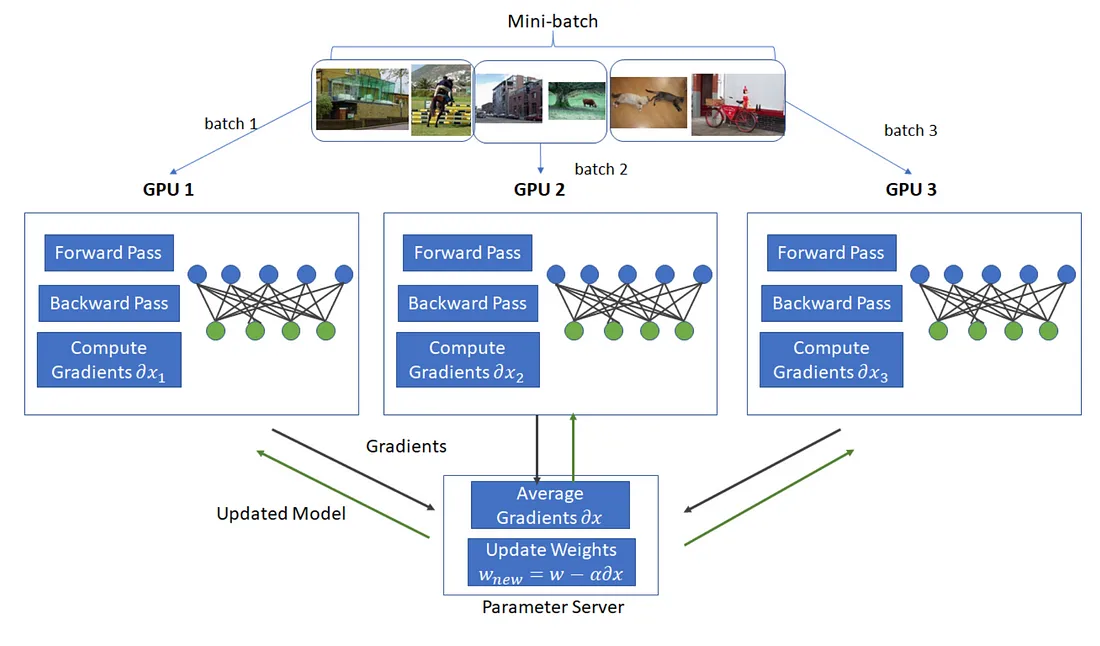
### **Data Parallelism**
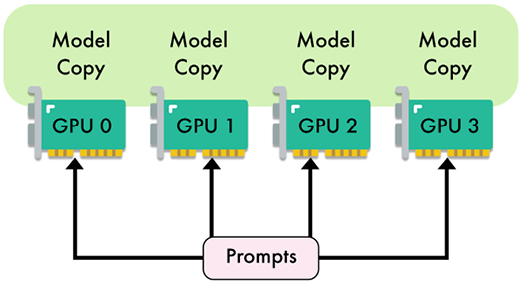
In data parallelism, the mini-batch is divided, and a copy of the model is available on each GPU. This speeds up model training by enabling multiple GPUs to work in parallel.
![](https://substackcdn.com/image/fetch/w_1456,c_limit,f_auto,q_auto:good,fl_progressive:steep/https%3A%2F%2Fsubstack-post-media.s3.amazonaws.com%2Fpublic%2Fimages%2F65192617-e486-406c-a64f-a4990457e387_2034x1016.png)

#### **How It Works**
1. The same model is replicated across all the GPUs.
2. Each GPU is fed a different subset of the input data (a unique mini-batch).
3. All GPUs independently perform forward and backward passes, computing their own local gradients.
4. The gradients are collected and averaged across all GPUs.
5. The averaged gradients are used to update the model's parameters.

#### **Advantages**
- **Faster Training:** Each GPU processes a unique mini-batch concurrently, reducing overall training time.
- Particularly effective for large datasets.

#### **Limitations**
- **Memory Constraints:** Each GPU must store a complete copy of the model and its parameters.
- Unsuitable for training very large models (e.g., ViTs or LLMs) that exceed a single GPU's memory capacity.


-   Replicating the model on each GPU can be inefficient for very large models because of redundant memory usage.
-   Synchronization overhead can become a bottleneck as the number of GPUs increases.

| Feature                           | DataParallel                                | DistributedDataParallel                      |
|-----------------------------------|---------------------------------------------|----------------------------------------------|
| **Setup**                         | Single machine, multiple GPUs               | Single/multiple machines, multiple GPUs       |
| **Model Replication**             | Model is copied from GPU 0 to all GPUs        | Model is replicated across GPUs; each GPU works locally |
| **Data Distribution**             | GPU 0 splits and distributes the batch         | Each GPU receives its mini-batch directly       |
| **Loss Computation**              | Centralized on GPU 0                         | Can be computed independently with decentralized gradient averaging |
| **Backward Pass**                 | Gradients are sent back to GPU 0 for averaging | Local gradients are averaged across GPUs       |
| **Communication Overhead**        | Higher on GPU 0 leading to potential bottlenecks | More efficient with distributed communication  |
| **Scalability**                   | Best for one machine                          | Scales efficiently to multiple machines        |
---
## 3. Model Parallelism

When the model is too large for a single GPU, **model parallelism** comes into play by splitting the model across devices. There are several sub-types:

### A. Naïve (Vertical) Model Parallelism

-   **Description:** The model is split layer-by-layer (e.g., assigning the first half of layers to GPU 0 and the second half to GPU 1).
-   **Limitation:** It can lead to idle GPUs (pipeline “bubbles”) due to sequential dependencies.

### B. Pipeline Parallelism

-   **Description:** The model’s layers are partitioned among GPUs, and the input batch is split into micro-batches. Each GPU processes a different micro-batch concurrently, and intermediate outputs (activations) are passed along the pipeline.
-   **Benefits:** Reduces idle time by overlapping computation and communication.

### **Tensor Parallelism**
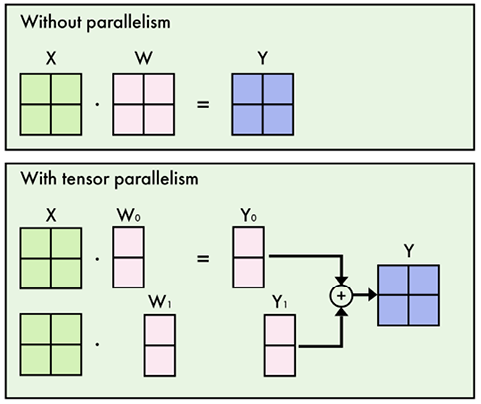
Unlike data parallelism, which divides the mini-batch across GPUs, tensor parallelism splits the **model itself** across multiple GPUs. This approach allows training of models that are too large to fit on a single GPU.
![](https://substackcdn.com/image/fetch/w_1456,c_limit,f_auto,q_auto:good,fl_progressive:steep/https%3A%2F%2Fsubstack-post-media.s3.amazonaws.com%2Fpublic%2Fimages%2Ff3f25e94-a68b-4adb-9241-01489d5c633b_1772x1002.png)
#### **How It Works**
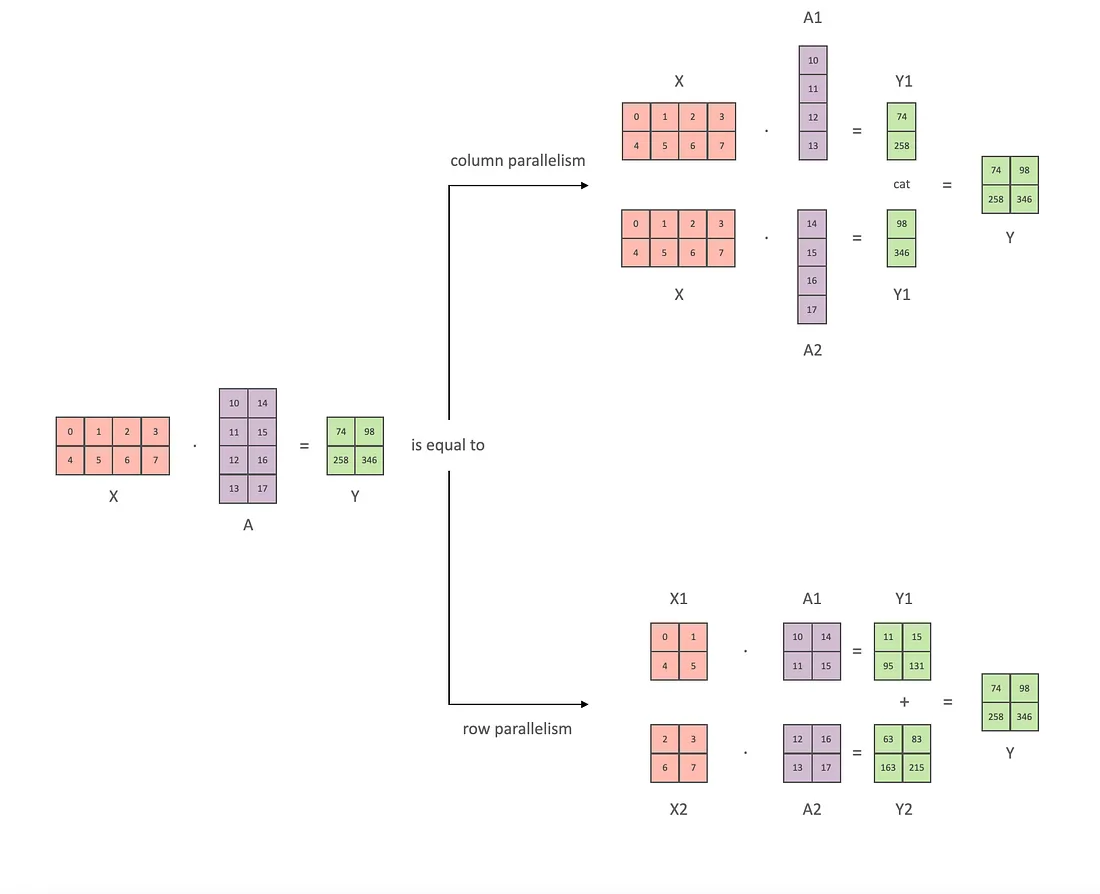
> If we split the weight matrix A column-wise across N GPUs and perform matrix multiplications XA_1 through XA_n in parallel, then we will end up with N output vectors Y_1, Y_2, ..., Y_n which can be fed into GeLU independently:
> 
- Tensor parallelism divides model operations (e.g., matrix multiplication) across GPUs.
- Example: For matrix multiplication, GPUs can divide the matrix by **rows** or **columns**:
  - Each GPU processes a smaller chunk of the operation.
  - The results are concatenated to reconstruct the original output.
- Effectively, this approach distributes both computation and memory load across GPUs.
- TP requires a very fast interconnect between devices. Therefore it’s not advisable to do TP across more than one node, unless you have a very fast network. 
![](https://substackcdn.com/image/fetch/w_1456,c_limit,f_auto,q_auto:good,fl_progressive:steep/https%3A%2F%2Fsubstack-post-media.s3.amazonaws.com%2Fpublic%2Fimages%2F87d0967d-5661-4813-919d-de3531cdcda3_2154x1146.png)
---

### **Comparison: Data Parallelism vs. Tensor Parallelism**

| **Aspect**                | **Data Parallelism**                                              | **Tensor Parallelism**                      |
|---------------------------|-------------------------------------------------------------------|--------------------------------------------|
| **Data Handling**          | Mini-batch divided across GPUs                                   | Model divided across GPUs                  |
| **Model on GPUs**          | Entire model replicated on each GPU                             | Model split into smaller shards            |
| **Memory Requirements**    | Requires each GPU to store the entire model and its parameters   | Reduces memory requirements per GPU        |
| **Use Case**               | Suitable for medium-sized models                                | Essential for very large models (e.g., LLMs) |

Tensor parallelism is especially valuable for modern models like Vision Transformers (ViTs) and Large Language Models (LLMs), which exceed the memory limits of a single GPU.

Here's an updated table with the trade-offs each approach resolves, and which method addresses them:

| **Approach**          | **Advantages**                                                                 | **Disadvantages**                                                   | **Trade-off Solved**                                  | **Ideal Scenario**                                               |
|------------------------|-------------------------------------------------------------------------------|----------------------------------------------------------------------|-------------------------------------------------------|-------------------------------------------------------------------|
| **Data Parallelism**   | - Simplifies implementation. <br> - Good for scaling across GPUs.             | - Increased memory usage. <br> - Redundant memory consumption.       | Resolves communication bottleneck in model updates.   | When dataset size is the limiting factor.                        |
| **Tensor Parallelism** | - Low latency. <br> - Efficient GPU memory usage.                            | - Increased communication overhead among GPUs.                       | Balances computational load between GPUs.             | When low latency is more important than memory efficiency.        |
| **Pipeline Parallelism**| - Reduces memory consumption the most.                                       | - Pipeline bubbles lead to reduced efficiency.                       | Addresses GPU memory constraints.                     | When fitting the model within GPU memory is the primary concern. |

By combining these techniques, practitioners can strategically mitigate issues and optimize the model's performance according to hardware and application needs. Let me know if you'd like additional refinements!

## 4. Asynchronous Synchronization

In contrast to the strict synchronization in data parallelism, **asynchronous synchronization** allows GPUs to perform computations without waiting for gradient aggregation at every step.

-   **Pros:** Overlapping communication with computation can reduce overall training time.
-   **Cons:** Risks using stale gradients, which may harm convergence if not carefully tuned.

----------

## 5. Hybrid Parallelism

**Hybrid Parallelism** combines the strengths of different approaches to maximize hardware utilization. For example, a training setup might use:

-   **Data Parallelism** across nodes to split the dataset.
-   **Pipeline Parallelism** to divide model layers among GPUs.
-   **Tensor Parallelism or FSDP** within each node to split or shard large tensors.

This multi-dimensional approach (sometimes called 3D parallelism) allows training extremely large models efficiently.

----------

## 6. Latest Research Example: mLoRA

A recent paper that exemplifies advanced parallelism in fine-tuning is:  
**"mLoRA: Fine-Tuning LoRA Adapters via Highly-Efficient Pipeline Parallelism in Multiple GPUs"**  
_(Published December 2023)_

[arxiv.org](https://arxiv.org/abs/2312.02515)

### Key Contributions of mLoRA:

-   **LoRA-aware Pipeline Parallelism:** mLoRA introduces a specialized scheme that pipelines independent LoRA adapters across GPUs, greatly reducing communication overhead.
-   **Efficient Operator:** A new operator enhances GPU utilization during pipelined LoRA training.
-   **Improved Fine-Tuning Efficiency:** The paper demonstrates a reduction in fine-tuning task completion time by about 30% compared to state-of-the-art methods like FSDP.
-   **Scalability:** mLoRA enables simultaneous fine-tuning of larger models (e.g., two Llama-2-13B models) on a modest number of high-end GPUs (four NVIDIA RTX A6000 48GB GPUs), which would otherwise be infeasible with conventional methods.

<!-- data-notebook-cell-style-version="2026-04-v2" -->
<h2 style="background:linear-gradient(90deg,#22313d 0%,#273743 100%);border-left:8px solid #72aa9b;color:#e7eff3;padding:11px 16px;border-radius:14px;border:1px solid #3a4b58;box-shadow:0 6px 18px rgba(0,0,0,0.18);margin:22px 0 14px 0;"><strong>Fully Sharded Data Parallelism (FSDP) – A Comprehensive Explanation</strong></h2>
<h2 style="background:linear-gradient(90deg,#22313d 0%,#273743 100%);border-left:8px solid #72aa9b;color:#e7eff3;padding:11px 16px;border-radius:14px;border:1px solid #3a4b58;box-shadow:0 6px 18px rgba(0,0,0,0.18);margin:22px 0 14px 0;"><strong>🔹 Introduction</strong></h2>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">Training large neural networks, especially <strong>Large Language Models (LLMs)</strong> like GPT or BERT, requires <strong>massive GPU memory</strong> and compute power. <strong>Fully Sharded Data Parallelism (FSDP)</strong> is an advanced <strong>distributed training technique</strong> that enables training models <strong>larger than a single GPU's memory</strong> by <strong>splitting the model’s parameters across multiple GPUs</strong> efficiently.</p>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">Let's consider a scenario with <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">n</code> GPUs and a model size denoted as <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">S</code>, in which the model cannot fit on one GPU but can fit on all the GPUs combined. After splitting the model “vertically,” each GPU has a slice of the model of size <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">S/n</code>. The time it takes for a single GPU to run the forward pass on its model slice is represented as <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">T_forward</code>, and the backward run time is denoted as <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">T_backward</code>.</p>
<h1 style="background:linear-gradient(135deg,#22313d 0%,#284740 100%);color:#edf5f3;padding:18px 22px;border-radius:20px;border:1px solid #3a5255;border-left:10px solid #78b0a1;box-shadow:0 10px 24px rgba(0,0,0,0.20);margin:0 0 18px 0;"><strong>🔹 Why is FSDP Needed?</strong></h1>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">When training deep learning models, <strong>memory limitations</strong> are a major challenge. Here’s why:</p>
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;"><strong>1️⃣ Single GPU Memory Limitations</strong></h3>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">GPUs have <strong>fixed memory sizes</strong> (e.g., 24GB for an NVIDIA RTX 4090).</li>
<li style="margin:6px 0;">Large models like GPT-3 require <strong>hundreds of gigabytes of memory</strong>.</li>
<li style="margin:6px 0;">A <strong>single GPU</strong> cannot handle such large models.</li>
</ul>
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;"><strong>2️⃣ Traditional Model Parallelism is Inefficient</strong></h3>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">One <strong>naive approach</strong> is to <strong>split the model vertically</strong> (pipeline parallelism):</p>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Example:</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Suppose a model has <strong>9 layers</strong>.</li>
<li style="margin:6px 0;">With <strong>3 GPUs</strong>, we assign:
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;"><strong>GPU 1 → Layers 1-3</strong></li>
<li style="margin:6px 0;"><strong>GPU 2 → Layers 4-6</strong></li>
<li style="margin:6px 0;"><strong>GPU 3 → Layers 7-9</strong></li>
</ul>
</li>
</ul>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>⚠️ Problem: Idle GPUs</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">The issue emerges when the first GPU completes its forward pass and intends to run forward pass on the next batch.  <strong>We cannot begin the next forward pass for the subsequent batches before updating the initial weights</strong>  of the first GPU model weights—<code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">so the first GPU must wait for all downstream GPUs to complete the forward pass and propagate their respective gradients backwards before its weights can be updated, resulting in significant idle time. Specifically, the first GPU waits for </code> <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">*T_forward*(n-1) + T_backward*(n-1)*</code>  before applying backward propagation for the first batch.</li>
<li style="margin:6px 0;">The first GPU <strong>must wait</strong> for the last GPU to complete the forward pass before updating its weights.</li>
<li style="margin:6px 0;">If <strong>T_forward</strong> is the time for a forward pass, the total delay is:</p>

$$
Tforward×(n−1)+Tbackward×(n−1)T_{forward} \times (n-1) + T_{backward} \times (n-1)
$$

<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"></li>
<li style="margin:6px 0;"><strong>Most of the GPUs remain idle for a long time</strong>, reducing efficiency.
<img src="https://blog.clika.io/content/images/2024/01/image_1.svg" alt="" /></li>
</ul>
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;"><strong>✅ Solution: Fully Sharded Data Parallelism (FSDP)</strong></h3>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">FSDP <strong>eliminates idle time</strong> and <strong>reduces memory usage</strong> by:</p>
<ol style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;"><strong>Splitting parameters across GPUs (sharding) instead of splitting layers.</strong></li>
<li style="margin:6px 0;"><strong>Sharing only required data</strong> instead of duplicating entire models.</li>
<li style="margin:6px 0;"><strong>Ensuring all GPUs work in parallel</strong> without long waiting times.</li>
</ol>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h1 style="background:linear-gradient(135deg,#22313d 0%,#284740 100%);color:#edf5f3;padding:18px 22px;border-radius:20px;border:1px solid #3a5255;border-left:10px solid #78b0a1;box-shadow:0 10px 24px rgba(0,0,0,0.20);margin:0 0 18px 0;"><strong>🔹 Understanding FSDP: Key Concepts</strong></h1>
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;"><strong>1️⃣ Vertical Splitting (Model Partitioning)</strong></h3>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Similar to pipeline parallelism, we <strong>split the model into units</strong> (groups of layers).</li>
<li style="margin:6px 0;">Each GPU is <strong>responsible for certain layers</strong>.</li>
<li style="margin:6px 0;">However, this is <strong>not enough alone</strong> to solve the memory issue.</li>
</ul>
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;"><strong>2️⃣ Horizontal Splitting (Sharding)</strong></h3>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Instead of <strong>storing entire layers</strong>, each GPU <strong>stores only a fraction of the model parameters</strong>.</li>
<li style="margin:6px 0;">This process is called <strong>sharding</strong>.</li>
</ul>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Example:</strong></p>
<blockquote style="margin:14px 0;padding:12px 16px;background:#24313d;border-left:5px solid #90b7a2;border-radius:14px;border:1px solid #3c4d5a;color:#d9e4ec;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">For example, in a model with 9 convolution layers, each unit is responsible for a specific range of layers. The first GPU unit might manage layers 1 to 3, the second unit, layers 4 to 6, and the last unit might oversee layers 7 to 9.</p>
</blockquote>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Suppose we have a model with <strong>3 fully connected layers</strong>.</li>
<li style="margin:6px 0;">Instead of storing <strong>one full layer per GPU</strong>, we store <strong>one-third of each layer on each GPU</strong>.</li>
</ul>
<blockquote style="margin:14px 0;padding:12px 16px;background:#24313d;border-left:5px solid #90b7a2;border-radius:14px;border:1px solid #3c4d5a;color:#d9e4ec;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">Throughout the training process, <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">collaboration among GPUs occurs as they share necessary shards—in doing so, we store redundant parameters and incur communication overhead between the GPUs</code>, but in doing so, we’re able to keep all the GPUs busy at all times.</p>
</blockquote>
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;">**</h3>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">3️⃣ Sharded Entities in PyTorch FSDP**</p>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">FSDP <strong>shards (divides) three main components</strong>:</p>
<h2 style="background:linear-gradient(90deg,#22313d 0%,#273743 100%);border-left:8px solid #72aa9b;color:#e7eff3;padding:11px 16px;border-radius:14px;border:1px solid #3a4b58;box-shadow:0 6px 18px rgba(0,0,0,0.18);margin:22px 0 14px 0;"><strong>FSDP (Fully Sharded Data Parallelism): Sharded Components</strong></h2>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">FSDP shards (divides) three main components during training:
Under the <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">FULL_SHARD</code> strategy, the following key entities are subjected to sharding:</p>
<table style="width:100%;border-collapse:collapse;background:#ffffff;font-size:0.96rem;margin:16px 0;border:1px solid #dde6ec;border-radius:16px;overflow:hidden;">
<thead>
<tr>
<th style="background:#f3f6f8;color:#24415c;padding:10px 12px;text-align:left;border:1px solid #dde6ec;font-weight:700;"><strong>Sharded Entity</strong></th>
<th style="background:#f3f6f8;color:#24415c;padding:10px 12px;text-align:left;border:1px solid #dde6ec;font-weight:700;"><strong>Description</strong></th>
<th style="background:#f3f6f8;color:#24415c;padding:10px 12px;text-align:left;border:1px solid #dde6ec;font-weight:700;"><strong>Why It Matters</strong></th>
</tr>
</thead>
<tbody>
<tr style="background:#f8fbff;">
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><strong>Model Parameters (MP)</strong></td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Weights, biases, and buffers</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Reduces memory usage by distributing them across GPUs</td>
</tr>
<tr>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><strong>Gradients (GRD)</strong></td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Computed during backpropagation</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Prevents memory bottlenecks in training</td>
</tr>
<tr style="background:#f8fbff;">
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><strong>Optimizer State (OS)</strong></td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Stores Adam momentum, variance, etc.</td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Saves memory while preserving training accuracy</td>
</tr>
</tbody>
</table>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">For OS: Typically, the data are retained in 32-bit floating-point format (FP32), ensuring precision during the optimization process.</p>
<h1 style="background:linear-gradient(135deg,#22313d 0%,#284740 100%);color:#edf5f3;padding:18px 22px;border-radius:20px;border:1px solid #3a5255;border-left:10px solid #78b0a1;box-shadow:0 10px 24px rgba(0,0,0,0.20);margin:0 0 18px 0;"><strong>🔹 Step-by-Step Breakdown of FSDP</strong></h1>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">Let’s assume we have <strong>3 GPUs</strong> and a model with <strong>9 layers</strong>. Each GPU is assigned <strong>3 layers</strong>.</p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;"><strong>shard:</strong>  a single chunk of the split entities  <strong>that is attached to a specific GPU</strong>  (contains a small portion of every entity across the entire model)</li>
<li style="margin:6px 0;">Activation (<strong>ACT</strong>): the activation calculated in each GPU separately during forward pass</li>
<li style="margin:6px 0;"><strong>unit</strong>: a part of the model with its assigned layers created by vertical model partition</li>
<li style="margin:6px 0;"><code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">MEM_total</code>: the memory size of all the parameters to be stored, i.e.,  <strong>MP + GRD + OS</strong>
<img src="https://blog.clika.io/content/images/2024/01/Group-1631.svg" alt="" /></li>
</ul>
<h2 style="background:linear-gradient(90deg,#22313d 0%,#273743 100%);border-left:8px solid #72aa9b;color:#e7eff3;padding:11px 16px;border-radius:14px;border:1px solid #3a4b58;box-shadow:0 6px 18px rgba(0,0,0,0.18);margin:22px 0 14px 0;"><strong>🔹 Step 1: Setup</strong></h2>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">1️⃣ <strong>Dataset Split</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">The dataset is <strong>split into 3 parts</strong>.</li>
<li style="margin:6px 0;">Each GPU handles a <strong>separate batch</strong>.</li>
</ul>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">2️⃣ <strong>Unit Assignment</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">The model is divided into <strong>units of layers</strong>.</li>
<li style="margin:6px 0;">Example:
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;"><strong>GPU 1 → Layers 1-3</strong></li>
<li style="margin:6px 0;"><strong>GPU 2 → Layers 4-6</strong></li>
<li style="margin:6px 0;"><strong>GPU 3 → Layers 7-9</strong></li>
</ul>
</li>
</ul>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">3️⃣ <strong>Sharding the Model</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">The parameters, optimizer states, and gradients are <strong>sharded across GPUs</strong>.</li>
<li style="margin:6px 0;">Each GPU <strong>stores only 1/3 of the total memory</strong> required.</li>
<li style="margin:6px 0;"></li>
</ul>
<h2 style="background:linear-gradient(90deg,#22313d 0%,#273743 100%);border-left:8px solid #72aa9b;color:#e7eff3;padding:11px 16px;border-radius:14px;border:1px solid #3a4b58;box-shadow:0 6px 18px rgba(0,0,0,0.18);margin:22px 0 14px 0;">💡 As mentioned, the sharding of the model entities is 'horizontal,' meaning that each shard includes model parameters from every layer, as shown in the following diagram:
<img src="https://blog.clika.io/content/images/2024/01/Group-1669.svg" alt="" /></h2>
<h2 style="background:linear-gradient(90deg,#22313d 0%,#273743 100%);border-left:8px solid #72aa9b;color:#e7eff3;padding:11px 16px;border-radius:14px;border:1px solid #3a4b58;box-shadow:0 6px 18px rgba(0,0,0,0.18);margin:22px 0 14px 0;"><strong>🔹 Step 2: Forward Pass</strong></h2>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">💡 <strong>Goal:</strong> Compute activations for each batch in parallel across GPUs.</p>
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;"><strong>Forward Pass Steps:</strong></h3>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">1️⃣ <strong>Broadcast Model Parameters</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Each GPU <strong>gathers the parameters</strong> for <strong>unit 1</strong> (MP 1).</li>
<li style="margin:6px 0;">This allows all GPUs to perform the <strong>forward pass in parallel</strong>.</li>
<li style="margin:6px 0;">
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;"><em>Broadcast model parameters:</em>  All GPUs will gather the model parameters of the first unit (MP 1) so they can run the first forward step.
<img src="https://blog.clika.io/content/images/2024/01/Group-1670.svg" alt="" /></li>
</ul>
</li>
</ul>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">2️⃣ <strong>Compute Forward Pass on Unit 1</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">Each GPU will run forward pass on unit 1 on its respective batch using the complete MP 1 that each GPU gathered from all the other GPUs</p>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">Since each GPU has <strong>different input batches</strong>, they compute different activations.
<img src="https://blog.clika.io/content/images/2024/01/Group-1671.svg" alt="" />
3️⃣ <strong>Store Activations (ACT)</strong></p>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">Each GPU <strong>saves its activations</strong> for later use in backpropagation.</p>
</li>
</ul>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">4️⃣ <strong>Reshard MP 1 (Free Memory)</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">MP 1 is <strong>deleted</strong> (except the portion owned by each GPU).
<img src="https://blog.clika.io/content/images/2024/01/Group-1672.svg" alt="" />
5️⃣ <strong>Repeat for Units 2 and 3</strong></p>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">The same steps are <strong>repeated for MP 2 and MP 3</strong>.</p>
</li>
<li style="margin:6px 0;"></li>
</ul>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><img src="https://blog.clika.io/content/images/2024/01/Group-1673.svg" alt="" />
6️⃣ <strong>Compute Loss</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">Each GPU computes <strong>loss</strong> for its respective batch.</li>
</ul>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h2 style="background:linear-gradient(90deg,#22313d 0%,#273743 100%);border-left:8px solid #72aa9b;color:#e7eff3;padding:11px 16px;border-radius:14px;border:1px solid #3a4b58;box-shadow:0 6px 18px rgba(0,0,0,0.18);margin:22px 0 14px 0;"><strong>🔹 Step 3: Backward Pass</strong></h2>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">💡 <strong>Goal:</strong> Compute gradients (GRD) and update model parameters.</p>
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;"><strong>Backward Pass Steps:</strong></h3>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">1️⃣ <strong>Broadcast Model Parameters for Unit 3</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">MP 3 is <strong>already available</strong> from the forward pass.</li>
<li style="margin:6px 0;">Therefore this step can be skipped for the unit 3 but is required for the backward pass of unit 2 and 1.</li>
</ul>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">2️⃣ <strong>Compute Backward Pass for Unit 3</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">Initiate backward propagation and update GRD using the ACT and MP on all GPUs for unit 3
<img src="https://blog.clika.io/content/images/2024/01/Group-1675.svg" alt="" />
3️⃣ <strong>Accumulate Gradients (Reduce-Scatter)</strong></p>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">All GPUs <strong>sum the computed gradients</strong> and distribute them evenly.</p>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">Take the GRD calculated in each GPU for unit 3, sum them to get the accumulated GRD, then distribute the accumulated GRD across the GPUs.
<img src="https://blog.clika.io/content/images/2024/01/Group-1679-1.svg" alt="" />
4️⃣ <strong>Reshard MP 3 and ACT (Free Memory)</strong></p>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">The memory used for MP 3 and ACT is <strong>freed</strong>.
<img src="https://blog.clika.io/content/images/2024/01/Group-1680-1.svg" alt="" /></p>
</li>
</ul>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">5️⃣ <strong>Repeat for Units 2 and 1</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">The process is repeated <strong>for all other units</strong>.</li>
<li style="margin:6px 0;"><img src="https://blog.clika.io/content/images/2024/01/Group-1681-1.svg" alt="" /></li>
</ul>
<h2 style="background:linear-gradient(90deg,#22313d 0%,#273743 100%);border-left:8px solid #72aa9b;color:#e7eff3;padding:11px 16px;border-radius:14px;border:1px solid #3a4b58;box-shadow:0 6px 18px rgba(0,0,0,0.18);margin:22px 0 14px 0;"><strong>🔹 Step 4: Optimizer Step</strong></h2>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">1️⃣ <strong>Update Model Parameters</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">The optimizer updates <strong>weights and optimizer states</strong>.</li>
<li style="margin:6px 0;"><img src="https://blog.clika.io/content/images/2024/01/Group-1682.svg" alt="" /></li>
</ul>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">2️⃣ <strong>Next Batch</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">The process repeats <strong>for the next batch</strong> until training is complete.</li>
</ul>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h1 style="background:linear-gradient(135deg,#22313d 0%,#284740 100%);color:#edf5f3;padding:18px 22px;border-radius:20px;border:1px solid #3a5255;border-left:10px solid #78b0a1;box-shadow:0 10px 24px rgba(0,0,0,0.20);margin:0 0 18px 0;"><strong>🔹 Benefits of FSDP</strong></h1>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Benefit</strong></p>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Why It’s Important</strong></p>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">✅ <strong>Efficient GPU Usage</strong></p>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">All GPUs work <strong>simultaneously</strong> instead of waiting.</p>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">✅ <strong>Lower Memory Requirements</strong></p>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">Each GPU holds only a <strong>fraction</strong> of the model.</p>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">✅ <strong>Scalable for Large Models</strong></p>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">Works well for models <strong>too large for a single GPU</strong>.</p>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">✅ <strong>Optimized Communication</strong></p>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">Uses <strong>reduce-scatter</strong> and <strong>broadcast</strong> to minimize overhead.</p>
<h2 style="background:linear-gradient(90deg,#22313d 0%,#273743 100%);border-left:8px solid #72aa9b;color:#e7eff3;padding:11px 16px;border-radius:14px;border:1px solid #3a4b58;box-shadow:0 6px 18px rgba(0,0,0,0.18);margin:22px 0 14px 0;"><strong>Important Functionalities of FSDP</strong></h2>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">FSDP (Fully Sharded Data Parallelism) provides several key mechanisms to optimize the distributed training of large models. Here’s a detailed explanation and breakdown of each functionality:</p>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;">1. Wrapping Policy</h3>
<div style="margin:14px 0;padding:12px 16px;background:#24313d;border-left:5px solid #90b7a2;border-radius:14px;border:1px solid #3c4d5a;color:#d9e4ec;line-height:1.75;"><p style="margin:6px 0;line-height:1.75;"><strong>Purpose:</strong> <br />
To ensure FSDP uses memory efficiently by controlling how model layers are grouped into separate FSDP units.</p></div>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>How It Works:</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Without Wrapping:</strong><br />
If a model (e.g., one with 100 layers) is not wrapped, all 100 layers are managed by a single FSDP unit. When gathering sharded parameters, the entire set of parameters for all 100 layers must be synchronized—no GPU memory is saved.</p>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>With Wrapping:</strong><br />
By applying a wrapping policy, you can set conditions (for instance, wrapping every 20 layers) to seal the current FSDP unit and start a new one. This means that only a subset of layers is handled at a time, saving GPU memory.</p>
</li>
</ul>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Important Note:</strong><br />
Focus on wrapping layers that include multi-attention and feedforward components, as these are the most memory intensive during training.</p>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;">2. MixedPrecision Policy</h3>
<div style="margin:14px 0;padding:12px 16px;background:#24313d;border-left:5px solid #90b7a2;border-radius:14px;border:1px solid #3c4d5a;color:#d9e4ec;line-height:1.75;"><p style="margin:6px 0;line-height:1.75;"><strong>Purpose:</strong> <br />
To offer flexibility in numerical precision for gradients and buffers, thereby optimizing both memory usage and training performance.</p></div>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Key Details:</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Precision Options:</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">It is recommended to use <strong>bfloat16</strong> for gradients and buffers since FP16 requires additional rescaling (and if not done precisely, it can degrade performance).</li>
<li style="margin:6px 0;">FSDP supports using different precisions for different variables, e.g., gradients on bf16 while buffers on fp16.</li>
</ul>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Default Behaviors:</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;"><strong>BatchNorm Layers:</strong> Automatically kept in FP32 for maintaining numerical stability. (This overrides any buffer precision setting.)</li>
<li style="margin:6px 0;"><strong>Local Gradients:</strong> Always computed in FP32 during backpropagation.</li>
<li style="margin:6px 0;"><strong>Model Saving:</strong> Models are saved in FP32 format to maximize portability, regardless of training precision.</li>
</ul>
</li>
</ul>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;">3. Backward Prefetch</h3>
<div style="margin:14px 0;padding:12px 16px;background:#24313d;border-left:5px solid #90b7a2;border-radius:14px;border:1px solid #3c4d5a;color:#d9e4ec;line-height:1.75;"><p style="margin:6px 0;line-height:1.75;"><strong>Purpose:</strong> <br />
To reduce training delays by overlapping communication with computation.</p></div>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>How It Works:</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Timing Control:</strong><br />
By setting the system to <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">BACKWARD_PRE</code>, FSDP can begin requesting parameters for the next unit before the current unit’s computation is fully finished.</p>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Benefit:</strong><br />
This overlapping of the all-gather communication (to fetch parameters) with the gradient computation on the current unit reduces overall communication overhead and speeds up training.</p>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Trade-Off:</strong><br />
It may use slightly more memory due to early parameter prefetching.</p>
</li>
</ul>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;">4. CPU Offloading</h3>
<div style="margin:14px 0;padding:12px 16px;background:#24313d;border-left:5px solid #90b7a2;border-radius:14px;border:1px solid #3c4d5a;color:#d9e4ec;line-height:1.75;"><p style="margin:6px 0;line-height:1.75;"><strong>Purpose:</strong> <br />
To enable training of models that are too large to fully reside in GPU memory even with sharding.</p></div>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>How It Works:</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Offloading Strategy:</strong><br />
When GPU memory is insufficient, parameters and gradients that exceed GPU capacity are offloaded to the CPU.</p>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Key Considerations:</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;"><strong>Implicit Gradient Offloading:</strong> Gradients are offloaded along with parameters to ensure they reside on the same device, a requirement for optimizer operations.</li>
<li style="margin:6px 0;"><strong>Performance Impact:</strong><br />
Frequent transfers between CPU and GPU can slow down training, but this trade-off allows for training larger-scale models that otherwise would be impossible.</li>
</ul>
</li>
</ul>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;">5. Activation Checkpointing</h3>
<div style="margin:14px 0;padding:12px 16px;background:#24313d;border-left:5px solid #90b7a2;border-radius:14px;border:1px solid #3c4d5a;color:#d9e4ec;line-height:1.75;"><p style="margin:6px 0;line-height:1.75;"><strong>Purpose:</strong> <br />
To reduce memory consumption during training at the cost of some recomputation during the backward pass.</p></div>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>How It Works:</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Selective Checkpointing:</strong><br />
Common practice involves checkpointing each transformer block. Only a subset of activations is stored, and the rest is recomputed during backpropagation.</p>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Impact:</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">For very large models (e.g., 13B parameters), this can increase throughput (reported increases around 10%).</li>
<li style="margin:6px 0;">For smaller models (e.g., 7B parameters), activation checkpointing may not be necessary.</li>
</ul>
</li>
</ul>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;">6. Sharding Strategies</h3>
<div style="margin:14px 0;padding:12px 16px;background:#24313d;border-left:5px solid #90b7a2;border-radius:14px;border:1px solid #3c4d5a;color:#d9e4ec;line-height:1.75;"><p style="margin:6px 0;line-height:1.75;"><strong>Purpose:</strong> <br />
To provide flexible options for splitting model components (parameters, optimizer states, gradients) across available GPUs.</p></div>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Available Strategies:</strong></p>
<table style="width:100%;border-collapse:collapse;background:#ffffff;font-size:0.96rem;margin:16px 0;border:1px solid #dde6ec;border-radius:16px;overflow:hidden;">
<thead>
<tr>
<th style="background:#f3f6f8;color:#24415c;padding:10px 12px;text-align:left;border:1px solid #dde6ec;font-weight:700;"><strong>Sharding Strategy</strong></th>
<th style="background:#f3f6f8;color:#24415c;padding:10px 12px;text-align:left;border:1px solid #dde6ec;font-weight:700;"><strong>Description</strong></th>
</tr>
</thead>
<tbody>
<tr style="background:#f8fbff;">
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><strong>FULL_SHARD (default)</strong></td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Shards all model components—parameters, optimizer states, and gradients—across GPUs.</td>
</tr>
<tr>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><strong>SHARD_GRAD_OP</strong></td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Keeps model parameters intact during the forward pass; helps reduce communication overhead.</td>
</tr>
<tr style="background:#f8fbff;">
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><strong>NO_SHARD</strong></td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Similar to traditional DDP where each GPU stores a full replica of the model.</td>
</tr>
<tr>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;"><strong>HYBRID_SHARD</strong></td>
<td style="padding:10px 12px;border:1px solid #e4edf2;vertical-align:top;color:#31475b;">Uses FULL_SHARD within individual nodes and NO_SHARD across nodes, balancing between efficiency and ease-of-use.</td>
</tr>
</tbody>
</table>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;">7. Checkpointing Type</h3>
<div style="margin:14px 0;padding:12px 16px;background:#24313d;border-left:5px solid #90b7a2;border-radius:14px;border:1px solid #3c4d5a;color:#d9e4ec;line-height:1.75;"><p style="margin:6px 0;line-height:1.75;"><strong>Purpose:</strong> <br />
To allow seamless resumption of training and to facilitate model deployment by saving state efficiently.</p></div>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>Options:</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>FULL_STATE_DICT:</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;"><strong>Process:</strong><br />
All parameters, optimizer states, and gradients are gathered to rank 0 (using its CPU memory) and then saved.</li>
<li style="margin:6px 0;"><strong>Limitation:</strong><br />
The maximum model size that can be saved is bounded by available CPU memory. Resuming training requires scattering these parameters back to other ranks.</li>
</ul>
</li>
<li style="margin:6px 0;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>SHARDED_STATE_DICT:</strong></p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;"><strong>Process:</strong><br />
Each GPU (rank) saves its own parameters, optimizer states, and gradients independently.</li>
<li style="margin:6px 0;"><strong>Advantage:</strong><br />
This removes the CPU memory limitation and is often better suited for very large models.</li>
</ul>
</li>
</ul>
<hr style="border:0;height:1px;background:linear-gradient(90deg,transparent,#556977,transparent);margin:20px 0;" />
<h2 style="background:linear-gradient(90deg,#22313d 0%,#273743 100%);border-left:8px solid #72aa9b;color:#e7eff3;padding:11px 16px;border-radius:14px;border:1px solid #3a4b58;box-shadow:0 6px 18px rgba(0,0,0,0.18);margin:22px 0 14px 0;"><strong>Summary</strong></h2>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">FSDP enhances large-scale model training through:</p>
<ul style="margin:10px 0 16px 20px;padding-left:18px;line-height:1.9;color:#d2dce4;">
<li style="margin:6px 0;"><strong>Wrapping Policy:</strong> Efficiently groups layers to minimize per-unit memory demand.</li>
<li style="margin:6px 0;"><strong>MixedPrecision Policy:</strong> Customizes numerical precision to strike a balance between speed and accuracy.</li>
<li style="margin:6px 0;"><strong>Backward Prefetch:</strong> Overlaps communication with computation, reducing delays.</li>
<li style="margin:6px 0;"><strong>CPU Offloading:</strong> Allows training of models too large to fit solely in GPU memory.</li>
<li style="margin:6px 0;"><strong>Activation Checkpointing:</strong> Lowers memory usage by re-computing activations while slightly increasing compute load.</li>
<li style="margin:6px 0;"><strong>Sharding Strategies:</strong> Offers multiple methods to partition model components best suited for your hardware and model size.</li>
<li style="margin:6px 0;"><strong>Checkpointing Types:</strong> Provides versatile saving and resuming techniques to ensure training can be continued reliably.</li>
</ul>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">Each of these functionalities works together to overcome the memory and computational limitations inherent in training very large models, making FSDP a robust solution for distributed deep learning.</p>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">🚀</p>


<!-- data-notebook-cell-style-version="2026-04-v2" -->
<h3 style="display:inline-block;color:#d8e4ea;background:#22303a;border-left:5px solid #7fa89e;padding:8px 14px;border-radius:12px;border:1px solid #3a4a52;margin:18px 0 10px 0;">Learning Rate:</h3>


<!-- data-notebook-cell-style-version="2026-04-v2" -->
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">Training large language models (LLMs) effectively requires strategies to stabilize and optimize the learning process. Three such techniques are <strong>learning rate warmup</strong>, <strong>cosine decay</strong>, and <strong>gradient clipping</strong>. Each plays a crucial role in enhancing model performance and training stability.</p>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>1. Learning Rate Warmup</strong></p>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">Learning rate warmup involves gradually increasing the learning rate from a low initial value to a predetermined peak value over a set number of steps at the beginning of training.</code></p>
<blockquote style="margin:14px 0;padding:12px 16px;background:#24313d;border-left:5px solid #90b7a2;border-radius:14px;border:1px solid #3c4d5a;color:#d9e4ec;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">This approach helps prevent large, destabilizing updates early in training, allowing the model to adjust smoothly.</p>
</blockquote>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><em>Implementation Example:</em></p>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">Suppose we plan to train an LLM for 15 epochs, starting with an initial learning rate of 0.0001 and increasing it to a peak learning rate of 0.01. If the total number of training steps is 135, setting the warmup phase to 20% of the total steps results in 27 warmup steps.</p>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">The number of warmup steps is usually set between 0.1% and 20% of the total number of steps, which we can calculate as follows:</p>
<pre style="background:#1b2330;color:#e6edf3;padding:14px 16px;border-radius:14px;border:1px solid #334155;overflow-x:auto;line-height:1.7;margin:14px 0;"><code class="language-python" style="background:transparent;color:#e6edf3;border:0;padding:0;">import torch

n_epochs = 15
initial_lr = 0.0001
peak_lr = 0.01
total_steps = len(train_loader) * n_epochs
warmup_steps = int(0.2 * total_steps)

optimizer = torch.optim.AdamW(model.parameters(), weight_decay=0.1)

lr_increment = (peak_lr - initial_lr) / warmup_steps

global_step = -1
track_lrs = []

for epoch in range(n_epochs):
    for input_batch, target_batch in train_loader:
        optimizer.zero_grad()
        global_step += 1

        if global_step &lt; warmup_steps:
            lr = initial_lr + global_step * lr_increment
        else:
            lr = peak_lr

        for param_group in optimizer.param_groups:
            param_group[&quot;lr&quot;] = lr
        track_lrs.append(lr)

</code></pre>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><img src="https://learning.oreilly.com/api/v2/epubs/urn:orm:book:9781633437166/files/Images/D-1.png" alt="figure" /></p>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>2. Cosine Decay</strong></p>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">After the warmup phase, <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">applying a cosine decay to the learning rate can further enhance training by gradually reducing the learning rate following a half-cosine cycle</code>.</p>
<pre style="background:#1b2330;color:#e6edf3;padding:14px 16px;border-radius:14px;border:1px solid #334155;overflow-x:auto;line-height:1.7;margin:14px 0;"><code class="language-python" style="background:transparent;color:#e6edf3;border:0;padding:0;">import math

min_lr = 0.1 * initial_lr
track_lrs = []
global_step = -1

for epoch in range(n_epochs):
    for input_batch, target_batch in train_loader:
        optimizer.zero_grad()
        global_step += 1

        if global_step &lt; warmup_steps:
            lr = initial_lr + global_step * lr_increment
        else:
            progress = (global_step - warmup_steps) / (total_steps - warmup_steps)
            lr = min_lr + (peak_lr - min_lr) * 0.5 * (1 + math.cos(math.pi * progress))

        for param_group in optimizer.param_groups:
            param_group[&quot;lr&quot;] = lr
        track_lrs.append(lr)

</code></pre>
<blockquote style="margin:14px 0;padding:12px 16px;background:#24313d;border-left:5px solid #90b7a2;border-radius:14px;border:1px solid #3c4d5a;color:#d9e4ec;">
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">This gradual reduction helps the model converge more smoothly and avoid overshooting minima.during the training process,</p>
</blockquote>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><img src="https://learning.oreilly.com/api/v2/epubs/urn:orm:book:9781633437166/files/Images/D-2.png" alt="figure" /></p>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>3. Gradient Clipping</strong></p>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">Gradient clipping is a technique used to prevent exploding gradients by capping the gradients during backpropagation to a predefined threshold. This ensures that the updates to the model's parameters remain within a manageable range, contributing to training stability.</p>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">Here, the term “norm” signifies the measure of the gradient vector’s length, or magnitude, within the model’s parameter space</code>, specifically referring to the L2 norm, also known as the Euclidean norm.</p>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">In mathematical terms, for a vector  <strong><em>v</em></strong>  composed of components  <strong><em>v</em></strong>  = [_v_1,  _v_2, ...,  <em>v__n</em>], the L2 norm is</p>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><img src="https://learning.oreilly.com/api/v2/epubs/urn:orm:book:9781633437166/files/Images/Equation-eqs-D-1.png" alt="figure" /></p>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">This calculation method is also applied to matrices. For instance, consider a gradient matrix given by</p>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><img src="https://learning.oreilly.com/api/v2/epubs/urn:orm:book:9781633437166/files/Images/Equation-eqs-D-2.png" alt="figure" /></p>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">If we want to clip these gradients to a  <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">max_norm</code>  of 1, we first compute the L2 norm of these gradients, which is</p>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><img src="https://learning.oreilly.com/api/v2/epubs/urn:orm:book:9781633437166/files/Images/Equation-eqs-D-3.png" alt="figure" /></p>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">Given that |<strong>G</strong>|2  = 5 exceeds our  <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">max_norm</code>  of 1, we scale down the gradients to ensure their norm equals exactly 1. This is achieved through a scaling factor, calculated as  <code style="background:#27313a;color:#e8eef4;padding:2px 6px;border-radius:6px;border:1px solid #3c4a55;">max_norm</code>/|<strong>G</strong>|2  = 1/5. Consequently, the adjusted gradient matrix  <strong>G'</strong>  becomes</p>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><img src="https://learning.oreilly.com/api/v2/epubs/urn:orm:book:9781633437166/files/Images/Equation-eqs-D-4.png" alt="figure" /></p>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">After computing the gradients via backpropagation, gradient clipping can be applied as follows:</p>
<pre style="background:#1b2330;color:#e6edf3;padding:14px 16px;border-radius:14px;border:1px solid #334155;overflow-x:auto;line-height:1.7;margin:14px 0;"><code class="language-python" style="background:transparent;color:#e6edf3;border:0;padding:0;">loss.backward()
torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
optimizer.step()

</code></pre>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">In this snippet, gradients are clipped to a maximum L2 norm of 1.0 before the optimizer updates the model parameters.</p>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;"><strong>4. Integrating the Techniques</strong></p>
<p style="margin:10px 0 15px 0;line-height:1.82;color:#d7e0e7;font-size:1rem;">Combining learning rate warmup, cosine decay, and gradient clipping can lead to more stable and efficient training of LLMs. The following function integrates these techniques into a training loop:</p>
<pre style="background:#1b2330;color:#e6edf3;padding:14px 16px;border-radius:14px;border:1px solid #334155;overflow-x:auto;line-height:1.7;margin:14px 0;"><code class="language-python" style="background:transparent;color:#e6edf3;border:0;padding:0;">import tiktoken

def train_model(model, train_loader, val_loader, optimizer, device,
                n_epochs, eval_freq, eval_iter, start_context, tokenizer,
                warmup_steps, initial_lr=3e-5, min_lr=1e-6):

    train_losses, val_losses, track_tokens_seen, track_lrs = [], [], [], []
    tokens_seen, global_step = 0, -1

    peak_lr = optimizer.param_groups[0][&quot;lr&quot;]
    total_steps = len(train_loader) * n_epochs
    lr_increment = (peak_lr - initial_lr) / warmup_steps

    for epoch in range(n_epochs):
        model.train()
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            global_step += 1

            if global_step &lt; warmup_steps:
                lr = initial_lr + global_step * lr_increment
            else:
                progress = (global_step - warmup_steps) / (total_steps - warmup_steps)
                lr = min_lr + (peak_lr - min_lr) * 0.5 * (1 + math.cos(math.pi * progress))

            for param_group in optimizer.param_groups:
                param_group[&quot;lr&quot;] = lr
            track_lrs.append(lr)

            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()

            if global_step &gt;= warmup_steps:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()
            tokens_seen += input_batch.numel()

            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader,
                    device, eval_iter
                )
                train_losses.append(train_loss)
 

</code></pre>
